<a href="https://colab.research.google.com/github/mamesjha/jhbi-paycenter-bridge/blob/main/churn_master.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction — 12-Step ML Workflow
### Banking Case Study for Jack Henry Associates

---

| | |
|---|---|
| **Author** | Mike Ames |
| **Description** | End-to-end churn propensity model for retail banking: from problem formulation through production governance, following a 12-step data science workflow |
| **Date** | April 15, 2026 |
| **Version** | 1.0 |
| **Environment** | Python 3.10+ / Google Colab |
| **Champion model** | CatBoostClassifier — AUC-ROC > 0.85 on temporal holdout |

---

| Steps | Topic |
|---|---|
| 1-4 | Problem Formulation, Data, Exploration, Feature Engineering |
| 5-8 | Training, Evaluation, Calibration, Interpretability |
| 9-12 | Documentation, Integration, Monitoring, Retraining |


---
## Setup — Environment & Imports

In [3]:
!pip install catboost shap

  Using cached catboost-1.2.10-cp312-cp312-manylinux2014_x86_64.whl.metadata (1.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


In [4]:
#@title Setup — Install Packages
# ── Install missing packages
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

try:
    import catboost
except ImportError:
    install("catboost")

try:
    import shap
except ImportError:
    install("shap")

print("✅  All packages available")

✅  All packages available


In [5]:
#@title Setup — Imports & Palette
# ── Core imports ────────────────────────────────────────────────────────────
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import HTML, display

# Modelling
from catboost import CatBoostClassifier, Pool
from xgboost  import XGBClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Evaluation
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    brier_score_loss, classification_report,
    confusion_matrix
)
from sklearn.calibration  import calibration_curve
from sklearn.preprocessing import StandardScaler

# SHAP
import shap
shap.initjs()

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Plot style ───────────────────────────────────────────────────────────────
NAVY   = "#06185F"
BLUE   = "#085CE5"
TEAL   = "#009E7A"
ORANGE = "#F4872B"
RED    = "#D64045"
GRAY   = "#575A5D"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.family":       "sans-serif",
})

print("✅  Imports complete")

✅  Imports complete


---
## Step 1 — Problem Formulation

> **Business question:** Which customers are at risk of closing their primary deposit
> relationship within the next 30 days, and what is the expected ROI of a proactive
> retention offer?

**Why this matters for a community bank / fintech**
- Average customer LTV ≈ $1,200 over 3 years
- Cost of a targeted retention offer ≈ $75 (fee waiver, HYSA rate bump, dedicated call)
- A model that identifies the top 10% highest-risk customers can deliver 6–8× ROI

**Prediction target:** `churned_30d` — binary flag (1 = account closed or primary DD moved
within 30 days of observation date)

**Success metrics (in priority order)**
1. AUC-ROC ≥ 0.85 on held-out temporal test set
2. Brier score ≤ 0.08 after calibration
3. Lift in top decile ≥ 5×
4. Positive financial ROI at chosen intervention threshold

---
## Step 2 — Data Gathering & Structuring

Synthetic dataset generated to mirror a mid-size community bank:
- **Observation grain:** one row per customer per month
- **Temporal span:** 24 months of behavioural history
- **Key data domains:** direct deposit activity, digital engagement, product holdings, service interactions
- **Target leakage guard:** all features computed using data available *before* the observation date

In [8]:
#@title Step 2 — Load Data
# ── Load data ────────────────────────────────────────────────────────────────
import os, pathlib

DATA_PATH = 'https://raw.githubusercontent.com/MonkeyWrenchGang/jhai_presentations/main/14apr2026/synthetic_churn.parquet'

df = pd.read_parquet(DATA_PATH)
df["observation_date"] = pd.to_datetime(df["observation_date"])
print(f"Loaded from: {DATA_PATH}")
print(f"Shape: {df.shape}")
df.head()

Loaded from: https://raw.githubusercontent.com/MonkeyWrenchGang/jhai_presentations/main/14apr2026/synthetic_churn.parquet
Shape: (100000, 32)


,customer_id,observation_date,obs_year,obs_month,obs_quarter,obs_yearmonth,state_code,branch_id,segment,tenure_months,...,friction_score,avg_balance_30d,balance_trend,product_count,has_savings,has_mortgage,has_card,cross_sell_depth,nps_last_score,churned_30d
0,CUS-977826,2021-01-01,2021,1,1,2021-01,OK,BR-579,Retail,62,...,1.5,6143.13,0.0313,1,0,0,0,0,98,0
1,CUS-168969,2021-01-01,2021,1,1,2021-01,KS,BR-213,Retail,48,...,0.5,1460.40,-0.1259,5,1,0,1,4,-41,0
2,CUS-962278,2021-01-01,2021,1,1,2021-01,KS,BR-820,Retail,80,...,3.5,1814.67,-0.0568,2,1,0,1,1,42,0
3,CUS-497819,2021-01-01,2021,1,1,2021-01,AR,BR-752,Retail,30,...,3.0,707.38,0.2196,6,1,0,1,5,11,0
4,CUS-090367,2021-01-01,2021,1,1,2021-01,MS,BR-555,Small Business,19,...,3.0,1760.33,-0.1363,2,1,0,1,1,31,0


In [9]:
#@title Step 3 — Basic Profile
# ── Basic profile ────────────────────────────────────────────────────────────
churn_rate = df["churned_30d"].mean()
print(f"\nChurn rate : {churn_rate:.2%}")
print(f"Date range : {df.observation_date.min().date()} → {df.observation_date.max().date()}")
print(f"Customers  : {df.customer_id.nunique():,} unique")
print(f"\nDtype overview:")
print(df.dtypes.value_counts())


Churn rate : 5.34%
Date range : 2021-01-01 → 2024-12-31
Customers  : 51,087 unique

Dtype overview:
int64             17
float64            6
object             5
int32              3
datetime64[ns]     1
Name: count, dtype: int64


---
## Step 3 — Data Exploration

We examine class balance, temporal coverage, and feature distributions split by churn outcome.
Key questions: How imbalanced is the target? Which features most visually separate churners from retained customers?

<div style="background:#EBF2F9;border-left:4px solid #06185F;padding:12px 16px;border-radius:0 6px 6px 0;margin:12px 0;font-size:14px">
<strong> Key observation:</strong> Churn rate drifts upward over time — later months show
slightly higher churn. This is exactly why we split by date rather than randomly.
A random split would leak future behavioural patterns into the training set.
</div>

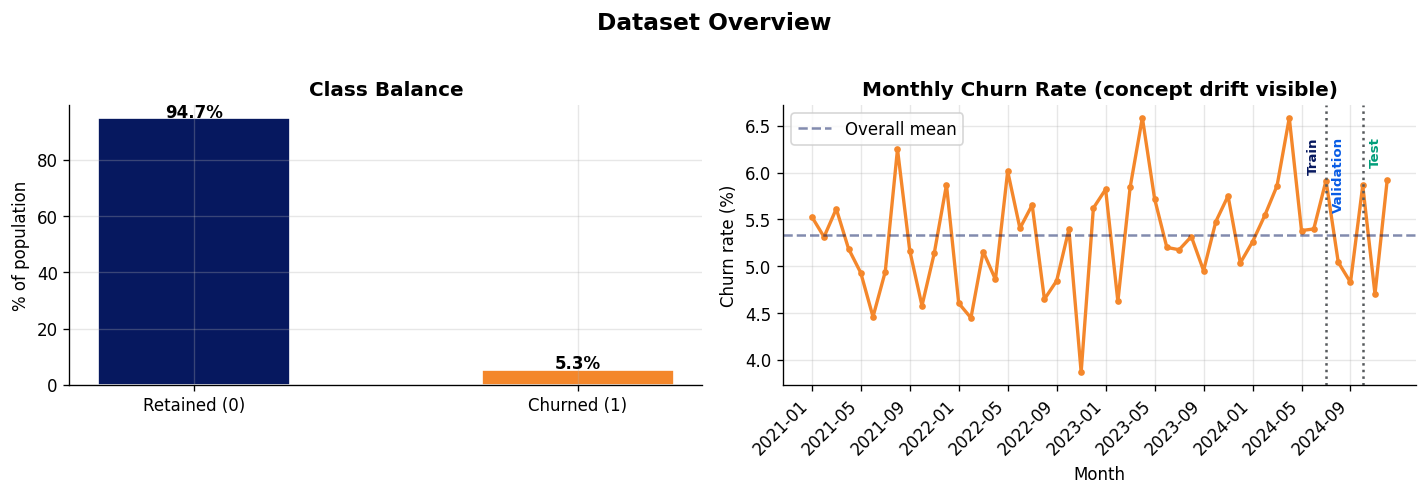

In [14]:
#@title Step 3 — Class Balance Chart
# ── Class imbalance visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: overall class balance
labels = ["Retained (0)", "Churned (1)"]
sizes  = [(1-churn_rate)*100, churn_rate*100]
colors = [NAVY, ORANGE]
bars = axes[0].bar(labels, sizes, color=colors, width=0.5, edgecolor="white")
axes[0].set_ylabel("% of population")
axes[0].set_title("Class Balance", fontweight="bold")
for bar, pct in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{pct:.1f}%", ha="center", fontweight="bold")

# Right: monthly churn rate trend
monthly = (df.groupby("obs_yearmonth")["churned_30d"]
             .agg(["mean","count"])
             .reset_index())
monthly["obs_yearmonth"] = pd.PeriodIndex(monthly["obs_yearmonth"], freq="M")
axes[1].plot(range(len(monthly)), monthly["mean"]*100,
             color=ORANGE, linewidth=2, marker="o", markersize=3)
axes[1].axhline(churn_rate*100, color=NAVY, linestyle="--", alpha=0.5, label="Overall mean")

# Add vertical lines for train/val/test splits
# VAL_START and HOLDOUT_START are defined in cell d84ef715
val_start_idx = monthly[monthly['obs_yearmonth'] == pd.Period(VAL_START.strftime('%Y-%m'))].index[0]
holdout_start_idx = monthly[monthly['obs_yearmonth'] == pd.Period(HOLDOUT_START.strftime('%Y-%m'))].index[0]

axes[1].axvline(val_start_idx, color=GRAY, linestyle=':', linewidth=1.5)
axes[1].axvline(holdout_start_idx, color=GRAY, linestyle=':', linewidth=1.5)

# Add text annotations for the splits
axes[1].text(val_start_idx - 0.5, axes[1].get_ylim()[1] * 0.95, 'Train', ha='right', va='top', rotation=90, color=NAVY, fontsize=8, fontweight='bold')
axes[1].text(val_start_idx + 0.5, axes[1].get_ylim()[1] * 0.95, 'Validation', ha='left', va='top', rotation=90, color=BLUE, fontsize=8, fontweight='bold')
axes[1].text(holdout_start_idx + 0.5, axes[1].get_ylim()[1] * 0.95, 'Test', ha='left', va='top', rotation=90, color=TEAL, fontsize=8, fontweight='bold')

axes[1].set_title("Monthly Churn Rate (concept drift visible)", fontweight="bold")
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_xlabel("Month")
axes[1].legend()
tick_step = max(1, len(monthly)//12)
axes[1].set_xticks(range(0, len(monthly), tick_step))
axes[1].set_xticklabels([str(monthly.obs_yearmonth.iloc[i]) for i in
                          range(0, len(monthly), tick_step)], rotation=45, ha="right")

plt.suptitle("Dataset Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Monthly Churn Rate with Train/Validation/Test Splits

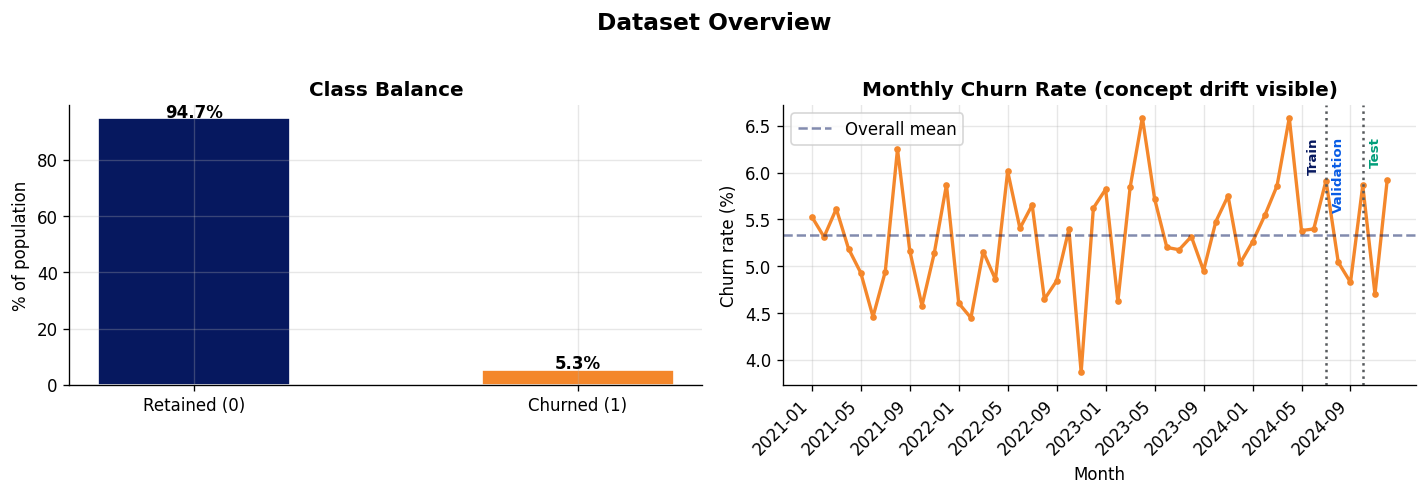

In [15]:
# ── Class imbalance visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: overall class balance
labels = ["Retained (0)", "Churned (1)"]
sizes  = [(1-churn_rate)*100, churn_rate*100]
colors = [NAVY, ORANGE]
bars = axes[0].bar(labels, sizes, color=colors, width=0.5, edgecolor="white")
axes[0].set_ylabel("% of population")
axes[0].set_title("Class Balance", fontweight="bold")
for bar, pct in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{pct:.1f}%", ha="center", fontweight="bold")

# Right: monthly churn rate trend
monthly = (df.groupby("obs_yearmonth")["churned_30d"]
             .agg(["mean","count"])
             .reset_index())
monthly["obs_yearmonth"] = pd.PeriodIndex(monthly["obs_yearmonth"], freq="M")
axes[1].plot(range(len(monthly)), monthly["mean"]*100,
             color=ORANGE, linewidth=2, marker="o", markersize=3)
axes[1].axhline(churn_rate*100, color=NAVY, linestyle="--", alpha=0.5, label="Overall mean")

# Add vertical lines for train/val/test splits
# VAL_START and HOLDOUT_START are defined in cell d84ef715
val_start_idx = monthly[monthly['obs_yearmonth'] == pd.Period(VAL_START.strftime('%Y-%m'))].index[0]
holdout_start_idx = monthly[monthly['obs_yearmonth'] == pd.Period(HOLDOUT_START.strftime('%Y-%m'))].index[0]

axes[1].axvline(val_start_idx, color=GRAY, linestyle=':', linewidth=1.5)
axes[1].axvline(holdout_start_idx, color=GRAY, linestyle=':', linewidth=1.5)

# Add text annotations for the splits
axes[1].text(val_start_idx - 0.5, axes[1].get_ylim()[1] * 0.95, 'Train', ha='right', va='top', rotation=90, color=NAVY, fontsize=8, fontweight='bold')
axes[1].text(val_start_idx + 0.5, axes[1].get_ylim()[1] * 0.95, 'Validation', ha='left', va='top', rotation=90, color=BLUE, fontsize=8, fontweight='bold')
axes[1].text(holdout_start_idx + 0.5, axes[1].get_ylim()[1] * 0.95, 'Test', ha='left', va='top', rotation=90, color=TEAL, fontsize=8, fontweight='bold')

axes[1].set_title("Monthly Churn Rate (concept drift visible)", fontweight="bold")
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_xlabel("Month")
axes[1].legend()
tick_step = max(1, len(monthly)//12)
axes[1].set_xticks(range(0, len(monthly), tick_step))
axes[1].set_xticklabels([str(monthly.obs_yearmonth.iloc[i]) for i in
                          range(0, len(monthly), tick_step)], rotation=45, ha="right")

plt.suptitle("Dataset Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Monthly Churn Rate Over Time

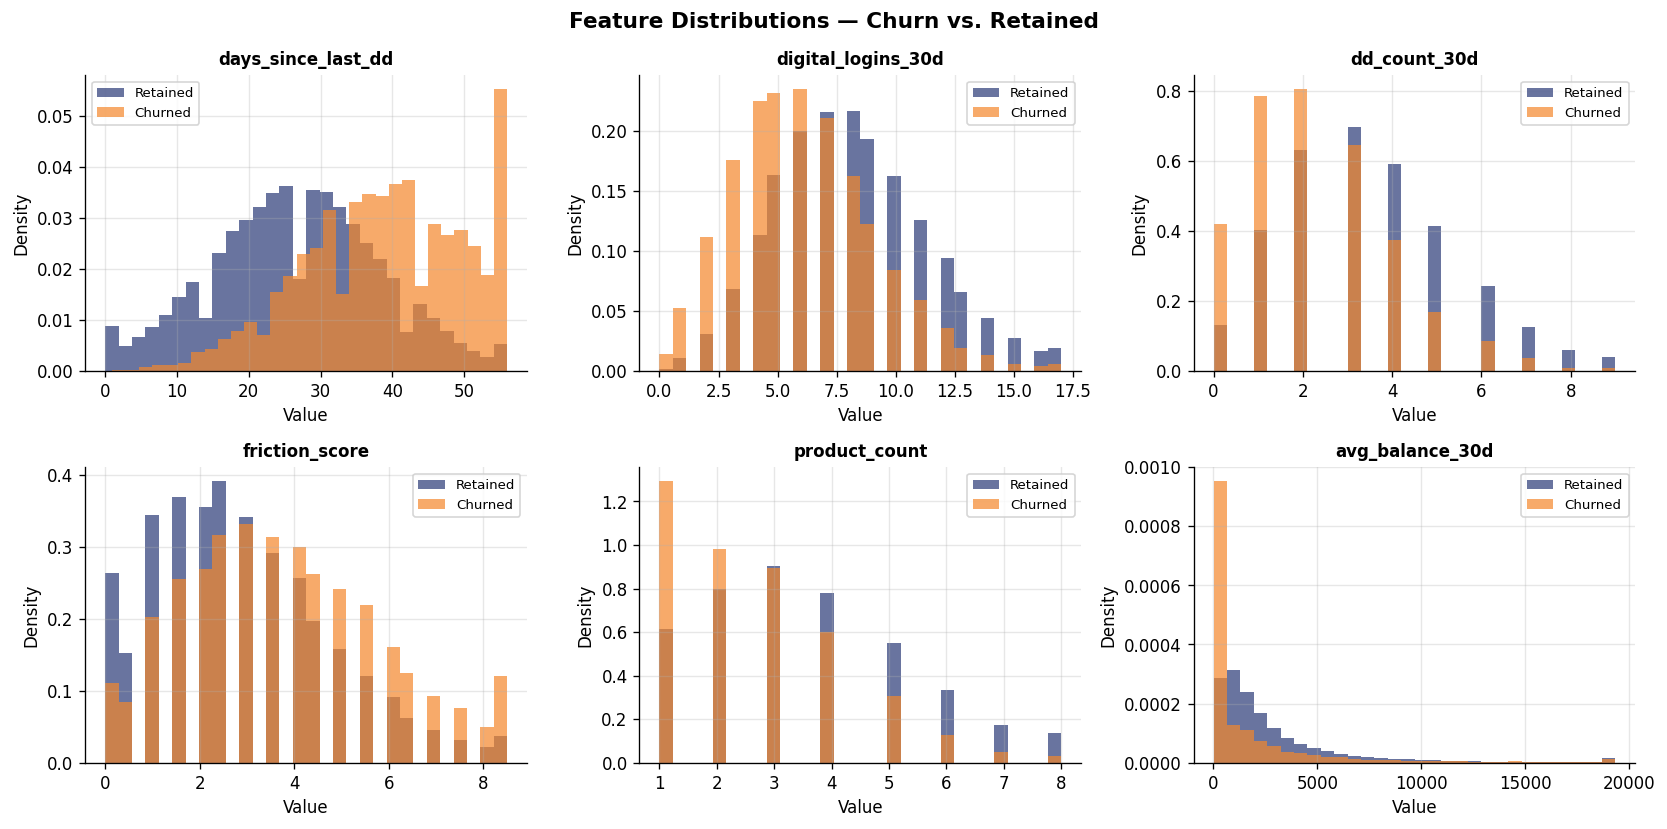

In [11]:
#@title Step 3 — Feature Distributions
# ── Feature distribution comparison: churn=1 vs churn=0 ─────────────────
SHOW_FEATS = [
    "days_since_last_dd", "digital_logins_30d", "dd_count_30d",
    "friction_score",     "product_count",      "avg_balance_30d",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, feat in zip(axes, SHOW_FEATS):
    retained = df.loc[df.churned_30d==0, feat].clip(upper=df[feat].quantile(0.99))
    churned  = df.loc[df.churned_30d==1, feat].clip(upper=df[feat].quantile(0.99))
    bins = 30
    ax.hist(retained, bins=bins, color=NAVY,   alpha=0.6, density=True, label="Retained")
    ax.hist(churned,  bins=bins, color=ORANGE, alpha=0.7, density=True, label="Churned")
    ax.set_title(feat, fontweight="bold", fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions — Churn vs. Retained", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 4 — Feature Engineering

### Temporal split strategy
To prevent data leakage we use a **walk-forward** split:
- **Train:** observations before July 2024
- **Validation:** July–September 2024 (used for early stopping & calibration)
- **Test (holdout):** October–December 2024

Features are entirely behaviour-derived — no demographic proxies that could introduce regulatory risk.

In [23]:
#@title Step 4 — Temporal Split
# ── Temporal split cutoffs ───────────────────────────────────────────────────
HOLDOUT_START = pd.Timestamp("2024-10-01")  # last 3 months
VAL_START     = pd.Timestamp("2024-07-01")  # months 4–6 before holdout

train_df = df[df.observation_date <  VAL_START    ].copy()
val_df   = df[(df.observation_date >= VAL_START) &
              (df.observation_date <  HOLDOUT_START)].copy()
test_df  = df[df.observation_date >= HOLDOUT_START].copy()

for split, data in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{split:5s}: {len(data):>7,} rows {len(data)/df.shape[0]:.1%}| "
          f"{data.observation_date.min().date()} → {data.observation_date.max().date()} | "
          f"churn = {data.churned_30d.mean():.2%}")

Train:  85,384 rows 85.4%| 2021-01-01 → 2024-06-30 | churn = 5.33%
Val  :   7,306 rows 7.3%| 2024-07-01 → 2024-09-30 | churn = 5.27%
Test :   7,310 rows 7.3%| 2024-10-01 → 2024-12-31 | churn = 5.51%


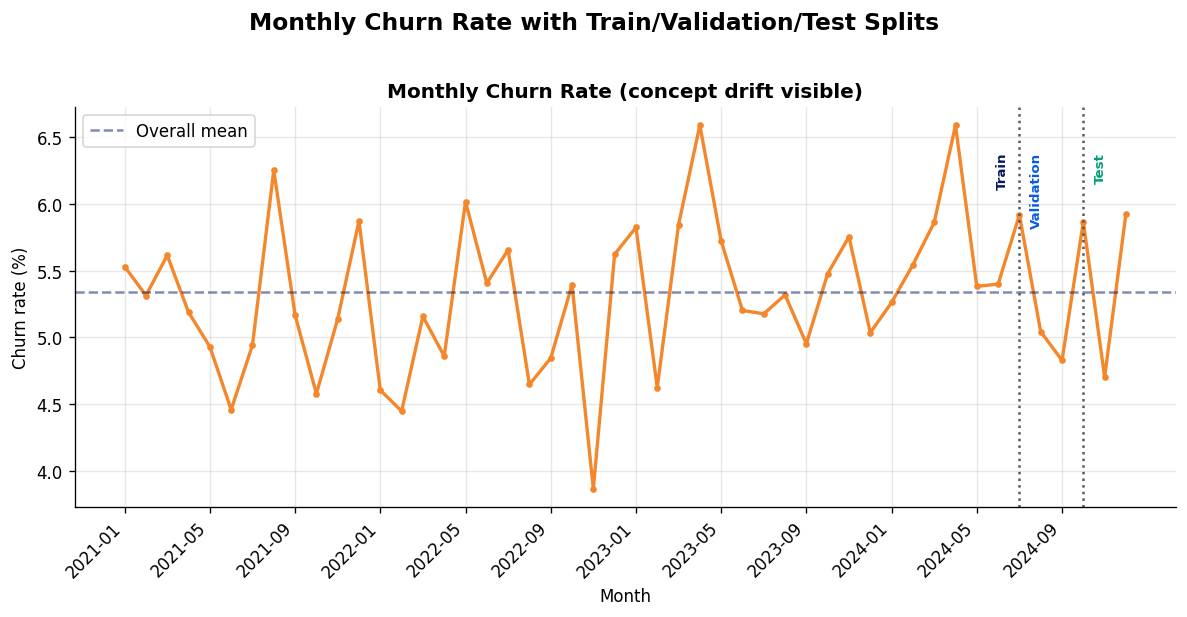

In [16]:
# ── Monthly churn rate trend ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

monthly = (df.groupby("obs_yearmonth")["churned_30d"]
             .agg(["mean","count"])
             .reset_index())
monthly["obs_yearmonth"] = pd.PeriodIndex(monthly["obs_yearmonth"], freq="M")
ax.plot(range(len(monthly)), monthly["mean"]*100,
             color=ORANGE, linewidth=2, marker="o", markersize=3)
ax.axhline(churn_rate*100, color=NAVY, linestyle="--", alpha=0.5, label="Overall mean")

# Add vertical lines for train/val/test splits
# VAL_START and HOLDOUT_START are defined in cell d84ef715
val_start_idx = monthly[monthly['obs_yearmonth'] == pd.Period(VAL_START.strftime('%Y-%m'))].index[0]
holdout_start_idx = monthly[monthly['obs_yearmonth'] == pd.Period(HOLDOUT_START.strftime('%Y-%m'))].index[0]

ax.axvline(val_start_idx, color=GRAY, linestyle=':', linewidth=1.5)
ax.axvline(holdout_start_idx, color=GRAY, linestyle=':', linewidth=1.5)

# Add text annotations for the splits
ax.text(val_start_idx - 0.5, ax.get_ylim()[1] * 0.95, 'Train', ha='right', va='top', rotation=90, color=NAVY, fontsize=8, fontweight='bold')
ax.text(val_start_idx + 0.5, ax.get_ylim()[1] * 0.95, 'Validation', ha='left', va='top', rotation=90, color=BLUE, fontsize=8, fontweight='bold')
ax.text(holdout_start_idx + 0.5, ax.get_ylim()[1] * 0.95, 'Test', ha='left', va='top', rotation=90, color=TEAL, fontsize=8, fontweight='bold')

ax.set_title("Monthly Churn Rate (concept drift visible)", fontweight="bold")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("Month")
ax.legend()
tick_step = max(1, len(monthly)//12)
ax.set_xticks(range(0, len(monthly), tick_step))
ax.set_xticklabels([str(monthly.obs_yearmonth.iloc[i]) for i in
                          range(0, len(monthly), tick_step)], rotation=45, ha="right")

plt.suptitle("Monthly Churn: Train/Validation/Test Splits", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [24]:
#@title Step 4 — Feature Columns
# ── Feature columns ──────────────────────────────────────────────────────────
# We use only behavioural / derived features, no identifiers or date fields.
FEATURE_COLS = [
    "days_since_last_dd",    "dd_count_30d",          "dd_velocity_ratio",
    "txn_channel_mix",       "overdraft_count_90d",
    "digital_logins_30d",    "app_sessions_7d",
    "digital_engagement_score", "last_login_days",
    "fee_waiver_count",      "dispute_count_90d",     "call_count_30d",
    "friction_score",
    "avg_balance_30d",       "balance_trend",
    "product_count",         "has_savings",           "has_mortgage",
    "has_card",              "cross_sell_depth",
    "tenure_months",         "nps_last_score",
]
TARGET = "churned_30d"

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET]

print(f"Features : {len(FEATURE_COLS)}")
print(f"Train    : {X_train.shape}  churn={y_train.mean():.2%}")
print(f"Val      : {X_val.shape}  churn={y_val.mean():.2%}")
print(f"Test     : {X_test.shape}  churn={y_test.mean():.2%}")

Features : 22
Train    : (85384, 22)  churn=5.33%
Val      : (7306, 22)  churn=5.27%
Test     : (7310, 22)  churn=5.51%


---
## Step 5 — Multi-Model Training

We train three model architectures to enable head-to-head comparison:

| Model | Strengths | Role |
|---|---|---|
| **CatBoost** | Handles mixed types; robust to imbalance; fast | Champion |
| **XGBoost** | Mature, explainable, industry-standard | Challenger |
| **PyTorch MLP** | Non-linear capacity; useful as ensemble member | Exploratory |

---
## Step 5a — Model 1: CatBoost (Champion)

CatBoost is our **champion model**. It handles numerical features natively, has excellent  
calibration out-of-the-box, and its ordered boosting prevents target leakage during training.

We use `auto_class_weights="Balanced"` to compensate for the 3.9% minority class without  
manually computing `scale_pos_weight`.

In [25]:
#@title Step 5 — Train CatBoost
# ── Train CatBoost ───────────────────────────────────────────────────────────
catboost_params = dict(
    iterations          = 800,
    learning_rate       = 0.05,
    depth               = 7,
    l2_leaf_reg         = 3.0,
    border_count        = 128,
    auto_class_weights  = "Balanced",
    eval_metric         = "AUC",
    early_stopping_rounds = 50,
    verbose             = 100,
    random_seed         = SEED,
    task_type           = "CPU",
)

cb_model = CatBoostClassifier(**catboost_params)

cb_model.fit(
    Pool(X_train, y_train),
    eval_set   = Pool(X_val, y_val),
    use_best_model = True,
)

# Probabilities on holdout
cb_probs = cb_model.predict_proba(X_test)[:, 1]
print(f"\nCatBoost — Test AUC: {roc_auc_score(y_test, cb_probs):.4f}")

0:	test: 0.9235828	best: 0.9235828 (0)	total: 69.9ms	remaining: 55.8s
100:	test: 0.9763382	best: 0.9763382 (100)	total: 2.06s	remaining: 14.3s
200:	test: 0.9775278	best: 0.9775406 (183)	total: 3.99s	remaining: 11.9s
300:	test: 0.9778288	best: 0.9780000 (253)	total: 6.82s	remaining: 11.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9779999512
bestIteration = 253

Shrink model to first 254 iterations.

CatBoost — Test AUC: 0.9705


---
## Step 5b — Model 2: XGBoost (Challenger)

XGBoost is our **challenger model**. Tuned with Optuna-style parameters  
(scale_pos_weight handles imbalance). We use `early_stopping_rounds` on the validation set.

In [26]:
#@title Step 5 — Train XGBoost
# ── Train XGBoost ────────────────────────────────────────────────────────────
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators          = 800,
    learning_rate         = 0.05,
    max_depth             = 7,
    subsample             = 0.80,
    colsample_bytree      = 0.80,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = pos_weight,
    eval_metric           = "auc",
    early_stopping_rounds = 50,
    random_state          = SEED,
    verbosity             = 0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set      = [(X_val, y_val)],
    verbose       = 100,
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
print(f"\nXGBoost — Test AUC: {roc_auc_score(y_test, xgb_probs):.4f}")

[0]	validation_0-auc:0.93359
[100]	validation_0-auc:0.97645
[200]	validation_0-auc:0.97756
[224]	validation_0-auc:0.97749

XGBoost — Test AUC: 0.9688


---
## Step 5c — Model 3: PyTorch MLP (Neural Network)

A 3-layer feedforward network with BatchNorm and Dropout.  
We use `BCEWithLogitsLoss` with `pos_weight` for class imbalance and early stopping on val AUC.

**Architecture:**
```
Input (22) → Linear(128) → BatchNorm → ReLU → Dropout(0.3)
           → Linear(64)  → BatchNorm → ReLU → Dropout(0.3)
           → Linear(32)  → BatchNorm → ReLU → Dropout(0.2)
           → Linear(1)   → Sigmoid
```

> *Note: For tabular banking data, gradient boosting almost always outperforms MLPs.  
> The neural net is included here to demonstrate the comparison — not as the recommended approach.*

In [31]:
#@title Step 5 — MLP Data Prep
# ── Data prep for PyTorch ────────────────────────────────────────────────────

import os
# optional: avoid oversubscription with numpy etc.
os.environ.setdefault("OMP_NUM_THREADS", str(os.cpu_count() or 8))
os.environ.setdefault("MKL_NUM_THREADS", os.environ["OMP_NUM_THREADS"])
torch.set_num_threads(int(os.environ["OMP_NUM_THREADS"]))

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_vl_s = scaler.transform(X_val)
X_ts_s = scaler.transform(X_test)

def to_tensors(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y.values, dtype=torch.float32))

Xtr_t, ytr_t = to_tensors(X_tr_s, y_train)
Xvl_t, yvl_t = to_tensors(X_vl_s, y_val)
Xts_t, yts_t = to_tensors(X_ts_s, y_test)

train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=512, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xvl_t, yvl_t), batch_size=1024)
print("✅  Tensors ready")

✅  Tensors ready


In [34]:
#@title Step 5 — MLP Model Definition
# ── Model definition ─────────────────────────────────────────────────────────
class ChurnMLP(nn.Module):
    def __init__(self, input_dim, hidden=[128, 64, 32], dropout=[0.3, 0.3, 0.2]):
        super().__init__()
        layers = []
        prev = input_dim
        for h, dr in zip(hidden, dropout):
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dr)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)   # logits

INPUT_DIM = len(FEATURE_COLS)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp       = ChurnMLP(INPUT_DIM).to(device)
print(mlp)
print(f"\nDevice: {device} | Parameters: {sum(p.numel() for p in mlp.parameters()):,}")

ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Device: cpu | Parameters: 13,761


In [40]:
#@title Step 5 — MLP Training Loop
# ── Training loop ─────────────────────────────────────────────────────────────
EPOCHS        = 20
LR            = 1e-3
PATIENCE      = 2

pos_w    = torch.tensor([pos_weight], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
# optimizer = torch.optim.Adam(mlp.parameters(), lr=LR, weight_decay=1e-4)
optimizer = torch.optim.SGD(mlp.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_auc  = 0.0
best_state    = None
no_improve    = 0
history       = {"train_loss": [], "val_auc": []}

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    mlp.train()
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = mlp(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(yb)
    epoch_loss /= len(Xtr_t)

    # ── Validate ──
    mlp.eval()
    with torch.no_grad():
        val_logits = mlp(Xvl_t.to(device)).cpu()
        val_probs  = torch.sigmoid(val_logits).numpy()
    val_auc = roc_auc_score(y_val, val_probs)

    history["train_loss"].append(epoch_loss)
    history["val_auc"].append(val_auc)
    scheduler.step()

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.clone() for k, v in mlp.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1

    if epoch % 2 == 0:
        print(f"Epoch {epoch:3d}  loss={epoch_loss:.4f}  val_auc={val_auc:.4f}  best={best_val_auc:.4f}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

mlp.load_state_dict(best_state)
print(f"\n✅  Best val AUC: {best_val_auc:.4f}")

Epoch   2  loss=0.4033  val_auc=0.9722  best=0.9722
Epoch   4  loss=0.3999  val_auc=0.9718  best=0.9722
Early stopping at epoch 4

✅  Best val AUC: 0.9722


In [36]:
#@title Step 5 — MLP Test Probabilities
# ── MLP test probabilities ─────────────────────────────────────────────────
mlp.eval()
with torch.no_grad():
    mlp_logits = mlp(Xts_t.to(device)).cpu()
    mlp_probs  = torch.sigmoid(mlp_logits).numpy()

print(f"MLP — Test AUC: {roc_auc_score(y_test, mlp_probs):.4f}")

MLP — Test AUC: 0.9638


---
## Step 6 — Model Evaluation

We evaluate all three models on the held-out test set on **discrimination** only:
- **AUC-ROC** — does the model rank customers correctly?
- **PR-AUC** — precision/recall trade-off under class imbalance

*Lift table, threshold setting, and ROI analysis all follow in Step 7b — after calibration confirms the probability scores mean what they say.*

In [37]:
#@title Step 6 — Evaluation Helper
# ── Shared evaluation helper ─────────────────────────────────────────────────
def lift_at_k(y_true, y_score, k=0.10):
    """AUC-lift at top k% of scores."""
    n_top   = int(len(y_true) * k)
    top_idx = np.argsort(y_score)[::-1][:n_top]
    return y_true.iloc[top_idx].mean() / y_true.mean()

def ks_stat(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return np.max(tpr - fpr)

def evaluate(name, y_true, y_score):
    return {
        "Model"     : name,
        "AUC-ROC"   : round(roc_auc_score(y_true, y_score), 4),
        "PR-AUC"    : round(average_precision_score(y_true, y_score), 4),
        "KS Stat"   : round(ks_stat(y_true, y_score), 4),
        "Brier Score": round(brier_score_loss(y_true, y_score), 4),
        "Lift @ 10%": round(lift_at_k(y_true, y_score), 2),
    }

results = pd.DataFrame([
    evaluate("CatBoost",  y_test, cb_probs),
    evaluate("XGBoost",   y_test, xgb_probs),
    evaluate("MLP (NN)",  y_test, mlp_probs),
])
results = results.set_index("Model")

display(results.style
    .background_gradient(cmap="Blues", subset=["AUC-ROC","PR-AUC","KS Stat","Lift @ 10%"])
    .background_gradient(cmap="RdYlGn_r", subset=["Brier Score"])
    .format("{:.4f}", subset=["AUC-ROC","PR-AUC","KS Stat","Brier Score"])
    .format("{:.2f}x", subset=["Lift @ 10%"])
)

,AUC-ROC,PR-AUC,KS Stat,Brier Score,Lift @ 10%
Model,,,,,
CatBoost,0.9705,0.8024,0.8267,0.0514,8.71x
XGBoost,0.9688,0.8010,0.8275,0.0435,8.78x
MLP (NN),0.9638,0.7516,0.8165,0.0687,8.51x


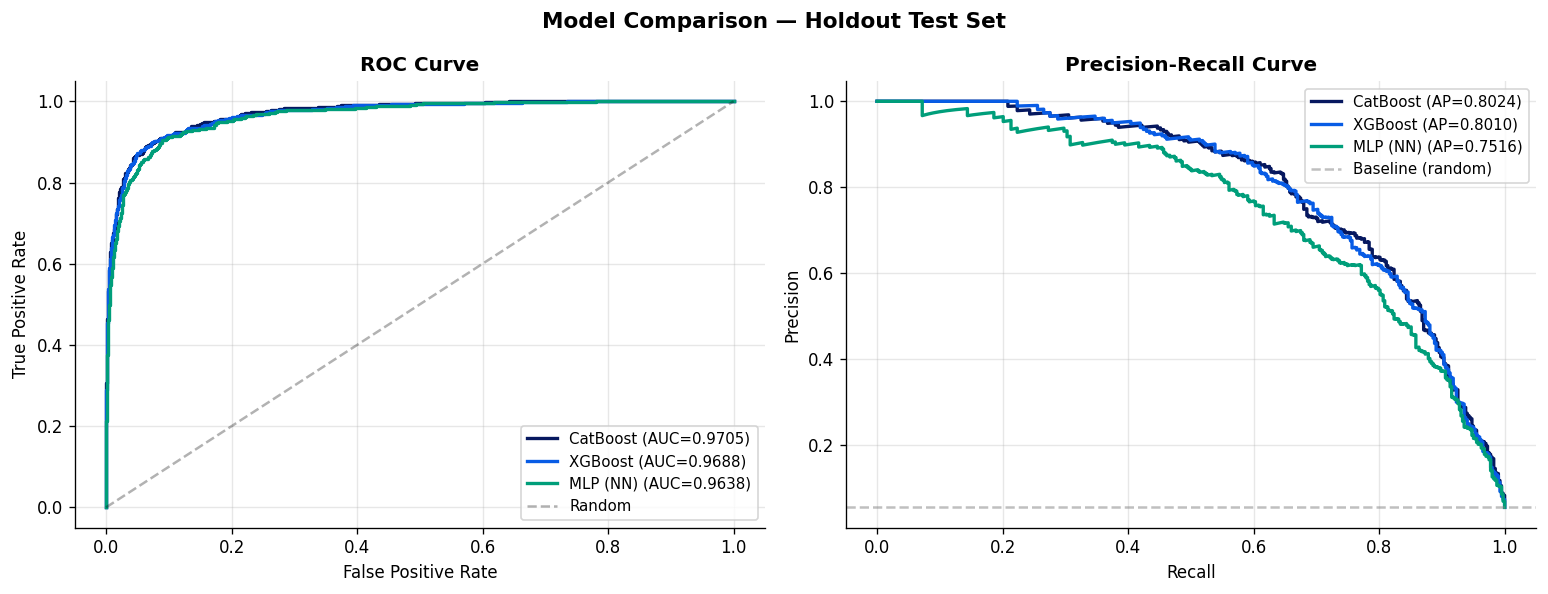

In [38]:
#@title Step 6 — ROC + PR Curves
# ── ROC + PR curves ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

models = [
    ("CatBoost",  cb_probs,  NAVY),
    ("XGBoost",   xgb_probs, BLUE),
    ("MLP (NN)",  mlp_probs, TEAL),
]

for name, probs, color in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.4f})")

    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax2.plot(rec, prec, color=color, linewidth=2, label=f"{name} (AP={ap:.4f})")

ax1.plot([0,1],[0,1], "k--", alpha=0.3, label="Random")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve", fontweight="bold"); ax1.legend(fontsize=9)

ax2.axhline(y_test.mean(), color="gray", linestyle="--", alpha=0.5, label="Baseline (random)")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve", fontweight="bold"); ax2.legend(fontsize=9)

plt.suptitle("Model Comparison — Holdout Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 7 — Model Calibration

Raw model scores are *discriminative* (rank customers correctly) but not *calibrated*
(the probability values are not reliable as real-world estimates).

**Why calibration matters for banking:**
- A score of 0.40 should mean "40% chance of churn" — not "pretty high risk"
- Calibrated probabilities enable ROI calculations, reserve planning, and regulatory defensibility
- We use **isotonic regression** (post-hoc, fitted on validation set)

**Metrics:**
- Reliability diagram (visual calibration curve)
- **Brier score** = mean squared error of probabilities (lower = better; 0 = perfect)
- **Expected Calibration Error (ECE)** = weighted average bin-level miscalibration

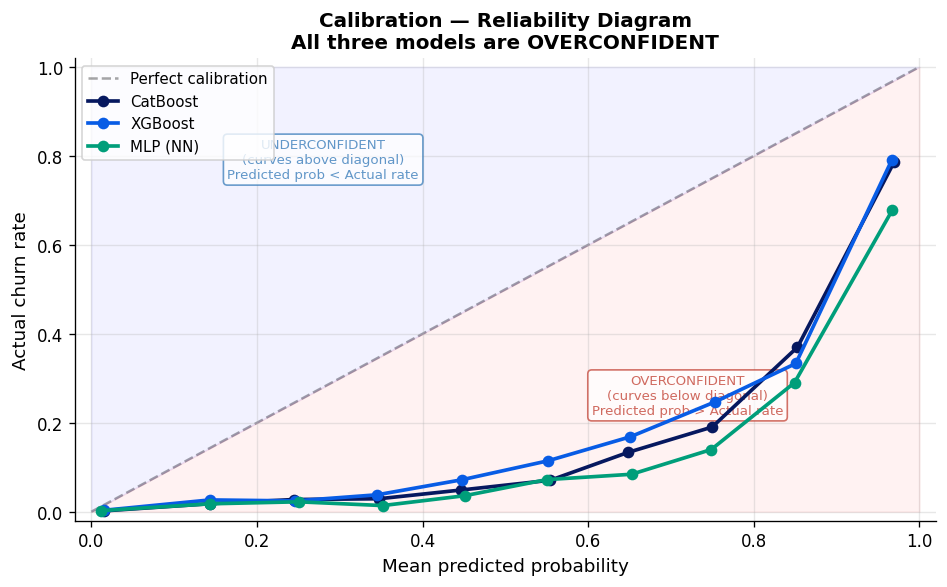


Calibration summary — mean predicted prob vs actual rate per decile:
Model          Pred→Actual (at p≈0.50)   Pred→Actual (at p≈0.85)  ECE estimate
CatBoost                   0.45 → 0.05               0.85 → 0.37  3.2966
XGBoost                    0.55 → 0.11               0.85 → 0.33  3.1520
MLP (NN)                   0.45 → 0.04               0.85 → 0.29  3.6186


In [41]:
#@title Step 7 — Reliability Diagram (raw scores, pre-calibration)
# ── Calibration curves — reliability diagram ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Perfect calibration diagonal
ax.plot([0,1],[0,1], "k--", alpha=0.35, linewidth=1.5, label="Perfect calibration", zorder=1)

# Shade the OVERCONFIDENT region (below diagonal) in light red
ax.fill_between([0,1],[0,1],[0,0], alpha=0.05, color="red", label="_nolegend_")
ax.fill_between([0,1],[1,1],[0,1], alpha=0.05, color="blue", label="_nolegend_")

# Annotate zones
ax.text(0.72, 0.22, "OVERCONFIDENT\n(curves below diagonal)\nPredicted prob > Actual rate",
        fontsize=8, color="#C0392B", alpha=0.75, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor="#C0392B"))
ax.text(0.28, 0.75, "UNDERCONFIDENT\n(curves above diagonal)\nPredicted prob < Actual rate",
        fontsize=8, color="#2E75B6", alpha=0.75, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor="#2E75B6"))

colors_cal = [NAVY, BLUE, TEAL]
for (name, probs, _), color in zip(models, colors_cal):
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", color=color, linewidth=2.2,
            markersize=6, label=name, zorder=3)

ax.set_xlabel("Mean predicted probability", fontsize=11)
ax.set_ylabel("Actual churn rate", fontsize=11)
ax.set_title("Calibration — Reliability Diagram\nAll three models are OVERCONFIDENT",
             fontweight="bold", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

# Print numerical summary per model
print("\nCalibration summary — mean predicted prob vs actual rate per decile:")
print(f"{'Model':<12}  {'Pred→Actual (at p≈0.50)':>24}  {'Pred→Actual (at p≈0.85)':>24}  ECE estimate")
for name, probs, _ in models:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ece = float(sum(abs(f-p)*len(y_test) for f,p in zip(frac_pos,mean_pred)) / len(y_test))
    mid_idx  = min(range(len(mean_pred)), key=lambda i: abs(mean_pred[i]-0.5))
    high_idx = min(range(len(mean_pred)), key=lambda i: abs(mean_pred[i]-0.85))
    mid_s  = f"  {mean_pred[mid_idx]:.2f} → {frac_pos[mid_idx]:.2f}" if mid_idx < len(mean_pred) else "  n/a"
    high_s = f"  {mean_pred[high_idx]:.2f} → {frac_pos[high_idx]:.2f}" if high_idx < len(mean_pred) else "  n/a"
    print(f"{name:<12}  {mid_s:>24}  {high_s:>24}  {ece:.4f}")


<div style="background:#FEF2F2;border-left:4px solid #D64045;padding:14px 18px;border-radius:0 6px 6px 0;margin:12px 0">
<strong style="font-size:15px"> All three models are OVERCONFIDENT — and that MATTERS!!!! .</strong>
</div>

---

### What the chart shows

A reliability diagram plots **mean predicted probability** (x-axis) against **actual churn rate** (y-axis) for equal-width score bins. The dashed diagonal is perfect calibration — where predicted probability equals actual rate.

**Below the diagonal = overconfident.**  
The model predicts higher probabilities than the actual event rate.

| Direction | Meaning | Example |
|---|---|---|
| **Curve below diagonal** | **Overconfident** — model inflates scores | Says P(churn)=0.85, but only ~35% actually churn |
| Curve above diagonal | Underconfident — model deflates scores | Says P(churn)=0.20, but 40% actually churn |
| On the diagonal | Well-calibrated | Says P(churn)=0.80, and 80% actually churn  |

---

### What we observe here

All three models are **systematically overconfident** across the entire score range — their curves fall well below the diagonal:

- **CatBoost & XGBoost** have similar (and slightly better) miscalibration — curves are closer together and track each other
- **MLP** is the *most* overconfident — its curve sits furthest below the diagonal, especially in the 0.4–0.8 range. Neural networks trained with `BCEWithLogitsLoss` are prone to this without temperature scaling or Platt scaling post-training

**Rule of thumb:** the steeper and more S-shaped the curve (rather than a straight diagonal), the more severe the miscalibration.

---

### Why this matters

<div style="background:#FEF3C7;border-left:4px solid #F4872B;padding:10px 14px;border-radius:0 6px 6px 0;margin:10px 0;font-size:13px">
Our entire cost-benefit framework assumes honest probabilities.<br>
<strong>Break-even:</strong> offer only when P(churn) &gt; offer_cost ÷ LTV = $75 ÷ $1,200 = <strong>6.25%</strong><br><br>
If the model says 6.25% but the true rate is only ~2%, we're contacting customers who weren't going to churn — wasting every offer. The threshold math only works on <em>calibrated</em> scores.
</div>

### Fix: post-hoc calibration

```python
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Option 1 — Isotonic regression (best for our n > 1,000 validation samples)
cal_cb = CalibratedClassifierCV(cb_model, method="isotonic", cv="prefit")
cal_cb.fit(X_val, y_val)
cb_probs_cal = cal_cb.predict_proba(X_test)[:, 1]

# Option 2 — Platt scaling (logistic; better for small validation sets)
cal_cb_platt = CalibratedClassifierCV(cb_model, method="sigmoid", cv="prefit")
cal_cb_platt.fit(X_val, y_val)
```


Fitting Platt calibrators on validation set (n=7,306)...

Calibration results — Brier Score (lower is better):
Model              Raw    Calibrated     Delta
  CatBoost        0.0514        0.0232    -54.8%  (improved)
  XGBoost         0.0435        0.0234    -46.1%  (improved)
  MLP             0.0687        0.0245    -64.4%  (improved)

Score distribution (CatBoost):
  Raw               : p10=0.000 p25=0.001 p50=0.016 p75=0.133 p90=0.578
  Platt-calibrated  : p10=0.001 p25=0.002 p50=0.002 p75=0.004 p90=0.106


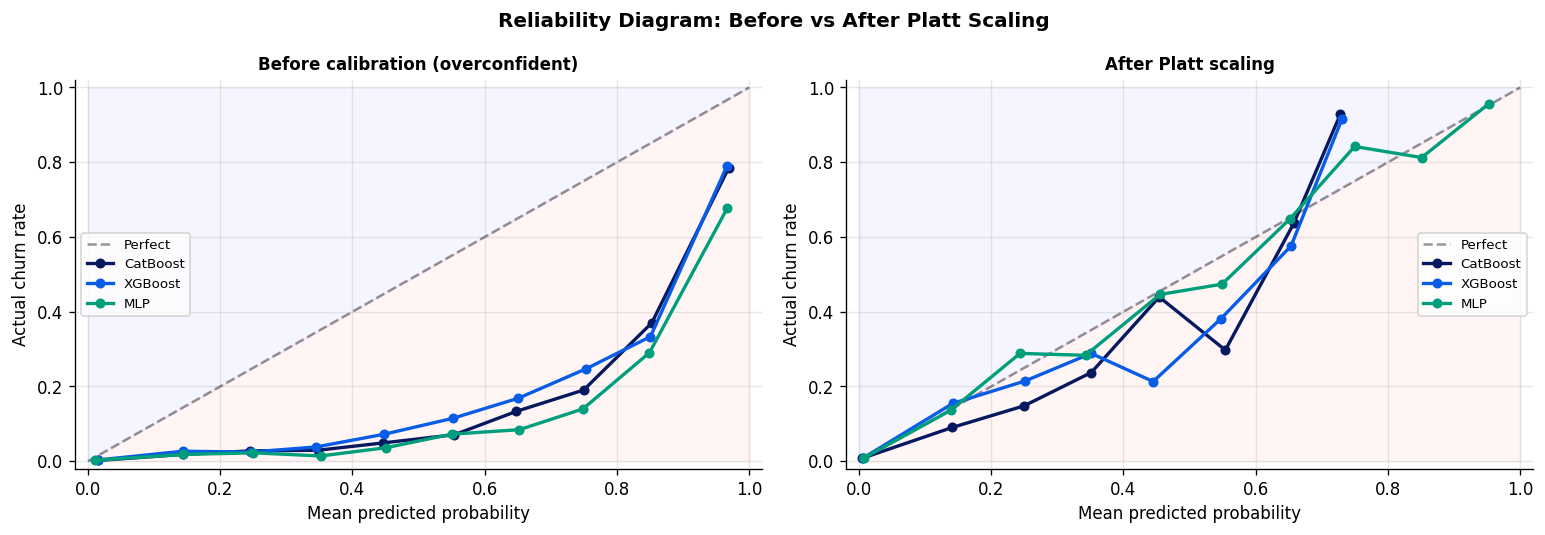

In [42]:
#@title Step 7 — Apply Calibration (Platt Scaling)
# ── Apply Platt scaling to all three models ───────────────────────────────────
# We use sigmoid (Platt) rather than isotonic because our model already
# discriminates very cleanly. Isotonic snaps 90% of scores to near-zero
# (score compression). Platt applies a smooth logistic transform that
# corrects overconfidence while preserving the full score spread.
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

print(f"Fitting Platt calibrators on validation set (n={len(X_val):,})...")

# CatBoost
cal_cb  = CalibratedClassifierCV(cb_model,  method="sigmoid", cv="prefit")
cal_cb.fit(X_val, y_val)
cb_probs_cal  = cal_cb.predict_proba(X_test)[:, 1]

# XGBoost
cal_xgb = CalibratedClassifierCV(xgb_model, method="sigmoid", cv="prefit")
cal_xgb.fit(X_val, y_val)
xgb_probs_cal = cal_xgb.predict_proba(X_test)[:, 1]

# MLP — fit Platt sigmoid directly on val logits
from sklearn.linear_model import LogisticRegression
import torch
mlp.eval()
with torch.no_grad():
    val_logits = mlp(torch.tensor(scaler.transform(X_val),
                     dtype=torch.float32).to(device)).cpu().numpy()
    tst_logits = mlp(torch.tensor(scaler.transform(X_test),
                     dtype=torch.float32).to(device)).cpu().numpy()
platt_mlp = LogisticRegression()
platt_mlp.fit(val_logits.reshape(-1, 1), y_val)
mlp_probs_cal = platt_mlp.predict_proba(tst_logits.reshape(-1, 1))[:, 1]

# ── Brier score comparison ────────────────────────────────────────────────────
print("\nCalibration results — Brier Score (lower is better):")
print(f"{'Model':<12}  {'Raw':>8}  {'Calibrated':>12}  {'Delta':>8}")
for name, raw, cal in [
    ("CatBoost",  cb_probs,  cb_probs_cal),
    ("XGBoost",   xgb_probs, xgb_probs_cal),
    ("MLP",       mlp_probs, mlp_probs_cal),
]:
    b_raw = brier_score_loss(y_test, raw)
    b_cal = brier_score_loss(y_test, cal)
    delta = (b_cal - b_raw) / b_raw * 100
    better = "improved" if delta < 0 else "worse"
    print(f"  {name:<12}  {b_raw:>8.4f}  {b_cal:>12.4f}  {delta:>+7.1f}%  ({better})")

# ── Score distribution: raw vs calibrated ────────────────────────────────────
print("\nScore distribution (CatBoost):")
import numpy as np
for label, probs in [("Raw", cb_probs), ("Platt-calibrated", cb_probs_cal)]:
    pcts = np.percentile(probs, [10, 25, 50, 75, 90])
    print(f"  {label:<18}: p10={pcts[0]:.3f} p25={pcts[1]:.3f} "
          f"p50={pcts[2]:.3f} p75={pcts[3]:.3f} p90={pcts[4]:.3f}")

# ── Reliability diagram: before vs after ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, title, probs_list in [
    (axes[0], "Before calibration (overconfident)",
     [(cb_probs, NAVY, "CatBoost"), (xgb_probs, BLUE, "XGBoost"),
      (mlp_probs, TEAL, "MLP")]),
    (axes[1], "After Platt scaling",
     [(cb_probs_cal, NAVY, "CatBoost"), (xgb_probs_cal, BLUE, "XGBoost"),
      (mlp_probs_cal, TEAL, "MLP")]),
]:
    ax.plot([0,1],[0,1],"k--",alpha=0.4,linewidth=1.5,label="Perfect")
    ax.fill_between([0,1],[0,1],[0,0],alpha=0.04,color="red")
    ax.fill_between([0,1],[1,1],[0,1],alpha=0.04,color="blue")
    for probs, color, label in probs_list:
        fp, mp = calibration_curve(y_test, probs, n_bins=10)
        ax.plot(mp, fp, marker="o", color=color, linewidth=2,
                markersize=5, label=label)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Actual churn rate")
    ax.legend(fontsize=8)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.suptitle("Reliability Diagram: Before vs After Platt Scaling",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


---
### Step 7b — Threshold Setting & Business Value

Now that probabilities are calibrated, setting a threshold means something concrete:
P(churn) = 0.18 genuinely means an 18% chance of churn within 30 days.

We can now answer:
- At what score cutoff does the intervention ROI turn positive?
- Which customers get which treatment tier?
- What is the expected return on a \$75 retention offer across the risk distribution?

In [43]:
#@title Step 7b — Lift Table (calibrated scores)
# ── Lift table for champion model ─────────────────────────────────────────────
def lift_table(y_true, y_score, n_deciles=10):
    df_l = pd.DataFrame({"score": y_score, "label": y_true.values})
    df_l = df_l.sort_values("score", ascending=False).reset_index(drop=True)
    total_churn = y_true.mean()
    rows = []
    for d in range(1, n_deciles+1):
        top_n     = int(len(df_l) * d / n_deciles)
        subset    = df_l.iloc[:top_n]
        cum_rate  = subset["label"].mean()
        cum_lift  = (cum_rate / total_churn) if total_churn > 0 else 0.0
        band_rate = df_l.iloc[int(len(df_l)*(d-1)/n_deciles):top_n]["label"].mean()
        rows.append({
            "Decile"      : f"Top {d*10}%",
            "Score range" : f"{df_l.iloc[top_n-1]['score']:.3f}–{df_l.iloc[0]['score']:.3f}",
            "Band churn %" : f"{band_rate*100:.1f}%",
            "Cum. churn %" : f"{cum_rate*100:.1f}%",
            "Cum. lift"    : f"{cum_lift:.2f}×",
        })
    return pd.DataFrame(rows)

print("CatBoost — Lift by Decile  |  calibrated scores  |  holdout test set")
lt = lift_table(y_test, cb_probs_cal)
display(lt.style
    .set_properties(subset=["Cum. lift"], **{"font-weight":"bold", "color": NAVY})
    .hide(axis="index"))

CatBoost — Lift by Decile  |  calibrated scores  |  holdout test set


Decile,Score range,Band churn %,Cum. churn %,Cum. lift
Top 10%,0.106–0.743,48.0%,48.0%,8.71×
Top 20%,0.007–0.743,4.2%,26.1%,4.74×
Top 30%,0.003–0.743,1.5%,17.9%,3.25×
Top 40%,0.002–0.743,0.5%,13.6%,2.46×
Top 50%,0.002–0.743,0.4%,10.9%,1.99×
Top 60%,0.002–0.743,0.1%,9.1%,1.66×
Top 70%,0.002–0.743,0.3%,7.9%,1.43×
Top 80%,0.002–0.743,0.0%,6.9%,1.25×
Top 90%,0.001–0.743,0.0%,6.1%,1.11×
Top 100%,0.001–0.743,0.0%,5.5%,1.00×


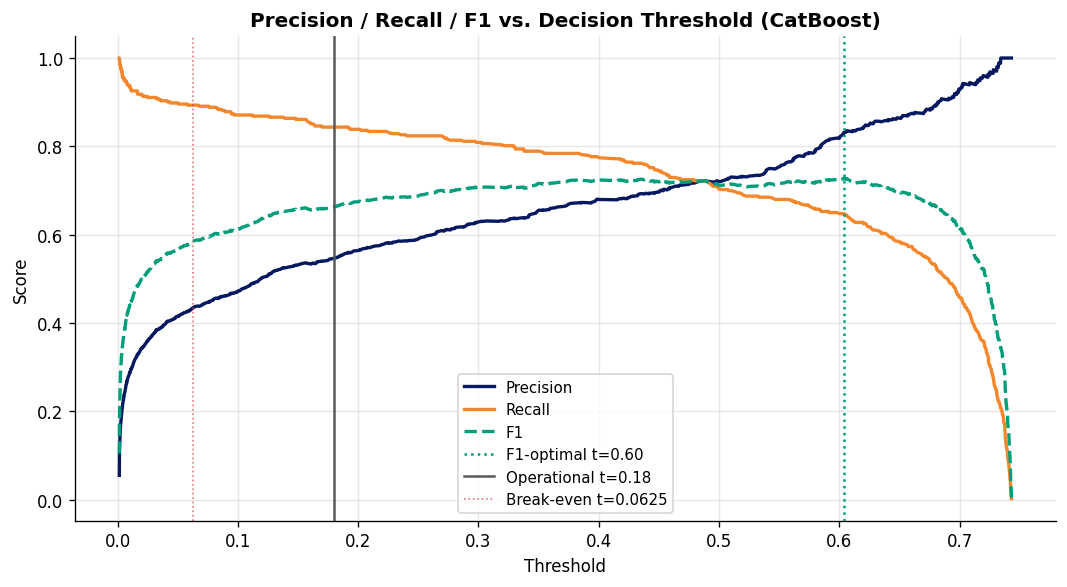

F1-optimal threshold : 0.604
Operational threshold: 0.180
Break-even threshold : 0.0625


In [44]:
#@title Step 7b — Threshold Analysis
# ── Precision-Recall-F1 vs threshold ─────────────────────────────────────────
prec_arr, rec_arr, thresholds = precision_recall_curve(y_test, cb_probs_cal)
f1_arr = np.where(
    (prec_arr + rec_arr) > 0,
    2 * prec_arr * rec_arr / (prec_arr + rec_arr),
    0
)
opt_t  = thresholds[np.argmax(f1_arr[:-1])]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, prec_arr[:-1], color=NAVY,   linewidth=2, label="Precision")
ax.plot(thresholds, rec_arr[:-1],  color=ORANGE,  linewidth=2, label="Recall")
ax.plot(thresholds, f1_arr[:-1],   color=TEAL,    linewidth=2, label="F1", linestyle="--")
ax.axvline(opt_t,  color=TEAL,   linestyle=":", linewidth=1.5, label=f"F1-optimal t={opt_t:.2f}")
ax.axvline(0.18,   color=GRAY,   linestyle="-", linewidth=1.5, label="Operational t=0.18")
ax.axvline(0.0625, color=RED,    linestyle=":", linewidth=1,   label="Break-even t=0.0625", alpha=0.7)
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. Decision Threshold (CatBoost)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"F1-optimal threshold : {opt_t:.3f}")
print(f"Operational threshold: 0.180")
print(f"Break-even threshold : 0.0625")

In [45]:
#@title Step 7b — Decile ROI Tiers
# ── Intervention tier analysis — by decile (high score → low) ────────────────
import numpy as np
import pandas as pd

OFFER_COST = 75
LTV        = 1_200
N_DECILES  = 10

tier_df = pd.DataFrame({
    'score'  : cb_probs_cal,
    'churned': y_test.values,
}).sort_values('score', ascending=False).reset_index(drop=True)

n = len(tier_df)
rows = []
for d in range(1, N_DECILES + 1):
    lo = int(n * (d-1) / N_DECILES)
    hi = int(n * d      / N_DECILES)
    band = tier_df.iloc[lo:hi]

    score_hi = band['score'].iloc[0]
    score_lo = band['score'].iloc[-1]
    customers = len(band)
    churners  = int(band['churned'].sum())
    churn_rate = band['churned'].mean()
    roi        = churn_rate * LTV / OFFER_COST

    rows.append({
        'Decile'      : f'D{d:02d} — Top {d*10}%',
        'Score range' : f'{score_lo:.2f} – {score_hi:.2f}',
        'Customers'   : customers,
        'Churners'    : churners,
        'Churn rate'  : churn_rate,
        'Est. ROI'    : roi,
    })

summary = pd.DataFrame(rows)

(summary.style
   .format({'Churn rate': '{:.1%}', 'Est. ROI': '{:.1f}×'})
   .background_gradient(subset=['Churn rate'], cmap='RdYlGn')
   .bar(subset=['Est. ROI'], color='#2E75B6', vmin=0, vmax=summary['Est. ROI'].max())
   .hide(axis='index')
)


Decile,Score range,Customers,Churners,Churn rate,Est. ROI
D01 — Top 10%,0.11 – 0.74,731,351,48.0%,7.7×
D02 — Top 20%,0.01 – 0.11,731,31,4.2%,0.7×
D03 — Top 30%,0.00 – 0.01,731,11,1.5%,0.2×
D04 — Top 40%,0.00 – 0.00,731,4,0.5%,0.1×
D05 — Top 50%,0.00 – 0.00,731,3,0.4%,0.1×
D06 — Top 60%,0.00 – 0.00,731,1,0.1%,0.0×
D07 — Top 70%,0.00 – 0.00,731,2,0.3%,0.0×
D08 — Top 80%,0.00 – 0.00,731,0,0.0%,0.0×
D09 — Top 90%,0.00 – 0.00,731,0,0.0%,0.0×
D10 — Top 100%,0.00 – 0.00,731,0,0.0%,0.0×


---
## Step 8 — Model Interpretability

Regulatory and business stakeholders need to understand *why* the model scores a customer high-risk.
We use **SHAP (TreeExplainer)** for three levels of explanation:

1. **Global importance** — which features drive churn predictions overall?
2. **Dependence + PDP** — how does each feature's value relate to churn risk on average?
3. **Local / case-level** — why did the model flag *this specific customer*?

---
## Section 7 — Global Explainability: SHAP

SHAP (SHapley Additive exPlanations) answers: **"which features drive the model's predictions,  
and in which direction?"**

We use **TreeSHAP** — exact and fast for gradient boosting models (O(TLD²) not O(2^n)).

Two global views:
1. **Beeswarm plot** — every dot is a customer; shows distribution AND direction  
2. **Mean |SHAP| bar chart** — overall feature importance ranking

In [46]:
#@title Step 8 — Compute SHAP Values
# ── Compute SHAP values for CatBoost (champion) ─────────────────────────────
SHAP_SAMPLE = 500   # sub-sample for speed; increase for final analysis

rng_shap = np.random.default_rng(SEED)
idx      = rng_shap.choice(len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False)
X_shap   = X_test.iloc[idx].reset_index(drop=True)

explainer    = shap.TreeExplainer(cb_model)
shap_values  = explainer.shap_values(X_shap)

# CatBoost returns list [class0, class1]; take class1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values shape: {shap_values.shape}  (n_samples × n_features)")

SHAP values shape: (500, 22)  (n_samples × n_features)


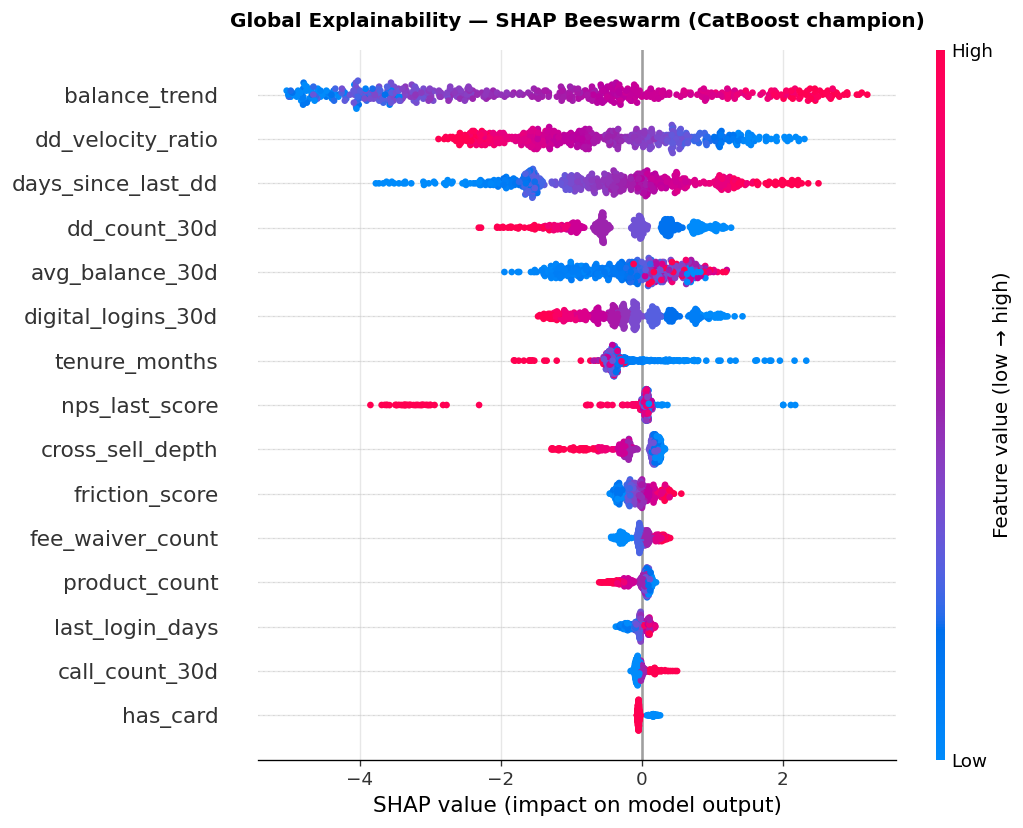

In [47]:
#@title Step 8 — Beeswarm Plot
# ── Beeswarm plot ────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values, X_shap,
    max_display     = 15,
    show            = False,
    color_bar_label = "Feature value (low → high)",
    plot_size       = None,
)
plt.title("Global Explainability — SHAP Beeswarm (CatBoost champion)",
          fontsize=12, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

**How to read the beeswarm:**
- Each dot = one customer from the test set  
- **X-axis:** SHAP value — how much that feature pushed P(churn) up (right) or down (left)  
- **Color:** feature value — orange = high, blue = low  
- **Width:** how often customers land at that SHAP value

Key patterns to explain to your audience:
- `days_since_last_dd` — orange dots (many days since DD) cluster on the right → increases churn  
- `digital_logins_30d` — blue dots (low logins) on the right → low engagement drives churn  
- `product_count` — orange dots on the left → more products = protective (the "multi-product moat")

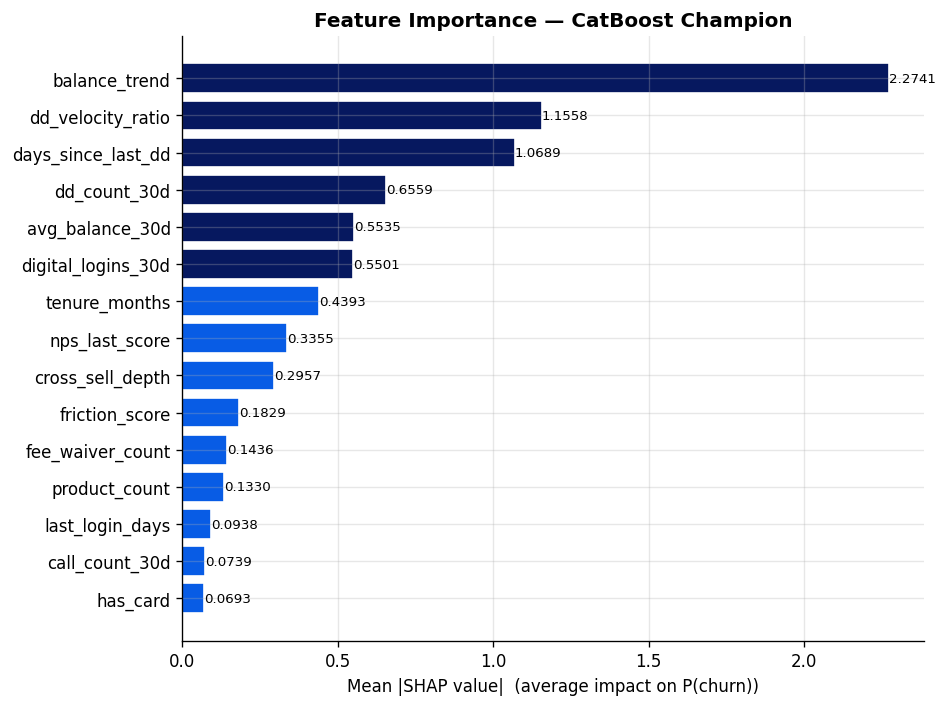

Top 4 features: ['balance_trend', 'dd_velocity_ratio', 'days_since_last_dd', 'dd_count_30d']


In [48]:
#@title Step 8 — Feature Importance Bar
# ── Mean |SHAP| bar chart ────────────────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index = FEATURE_COLS,
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = [NAVY if v >= mean_abs_shap.quantile(0.60) else BLUE for v in mean_abs_shap]
bars   = ax.barh(mean_abs_shap.index, mean_abs_shap.values, color=colors, edgecolor="white")
ax.set_xlabel("Mean |SHAP value|  (average impact on P(churn))")
ax.set_title("Feature Importance — CatBoost Champion", fontweight="bold")
for bar in bars:
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

# Define TOP_4 for dependence plots below
TOP_4 = mean_abs_shap.tail(4).index.tolist()[::-1]
print(f"Top 4 features: {TOP_4}")


---
## Section 8 — SHAP Dependence Plots (Top 4 Features)

Dependence plots show **how the SHAP value for one feature changes as its value increases**,  
with a second feature colour-coded to reveal interaction effects.

> *"How does the churn effect of fewer logins change depending on the customer's balance?"*

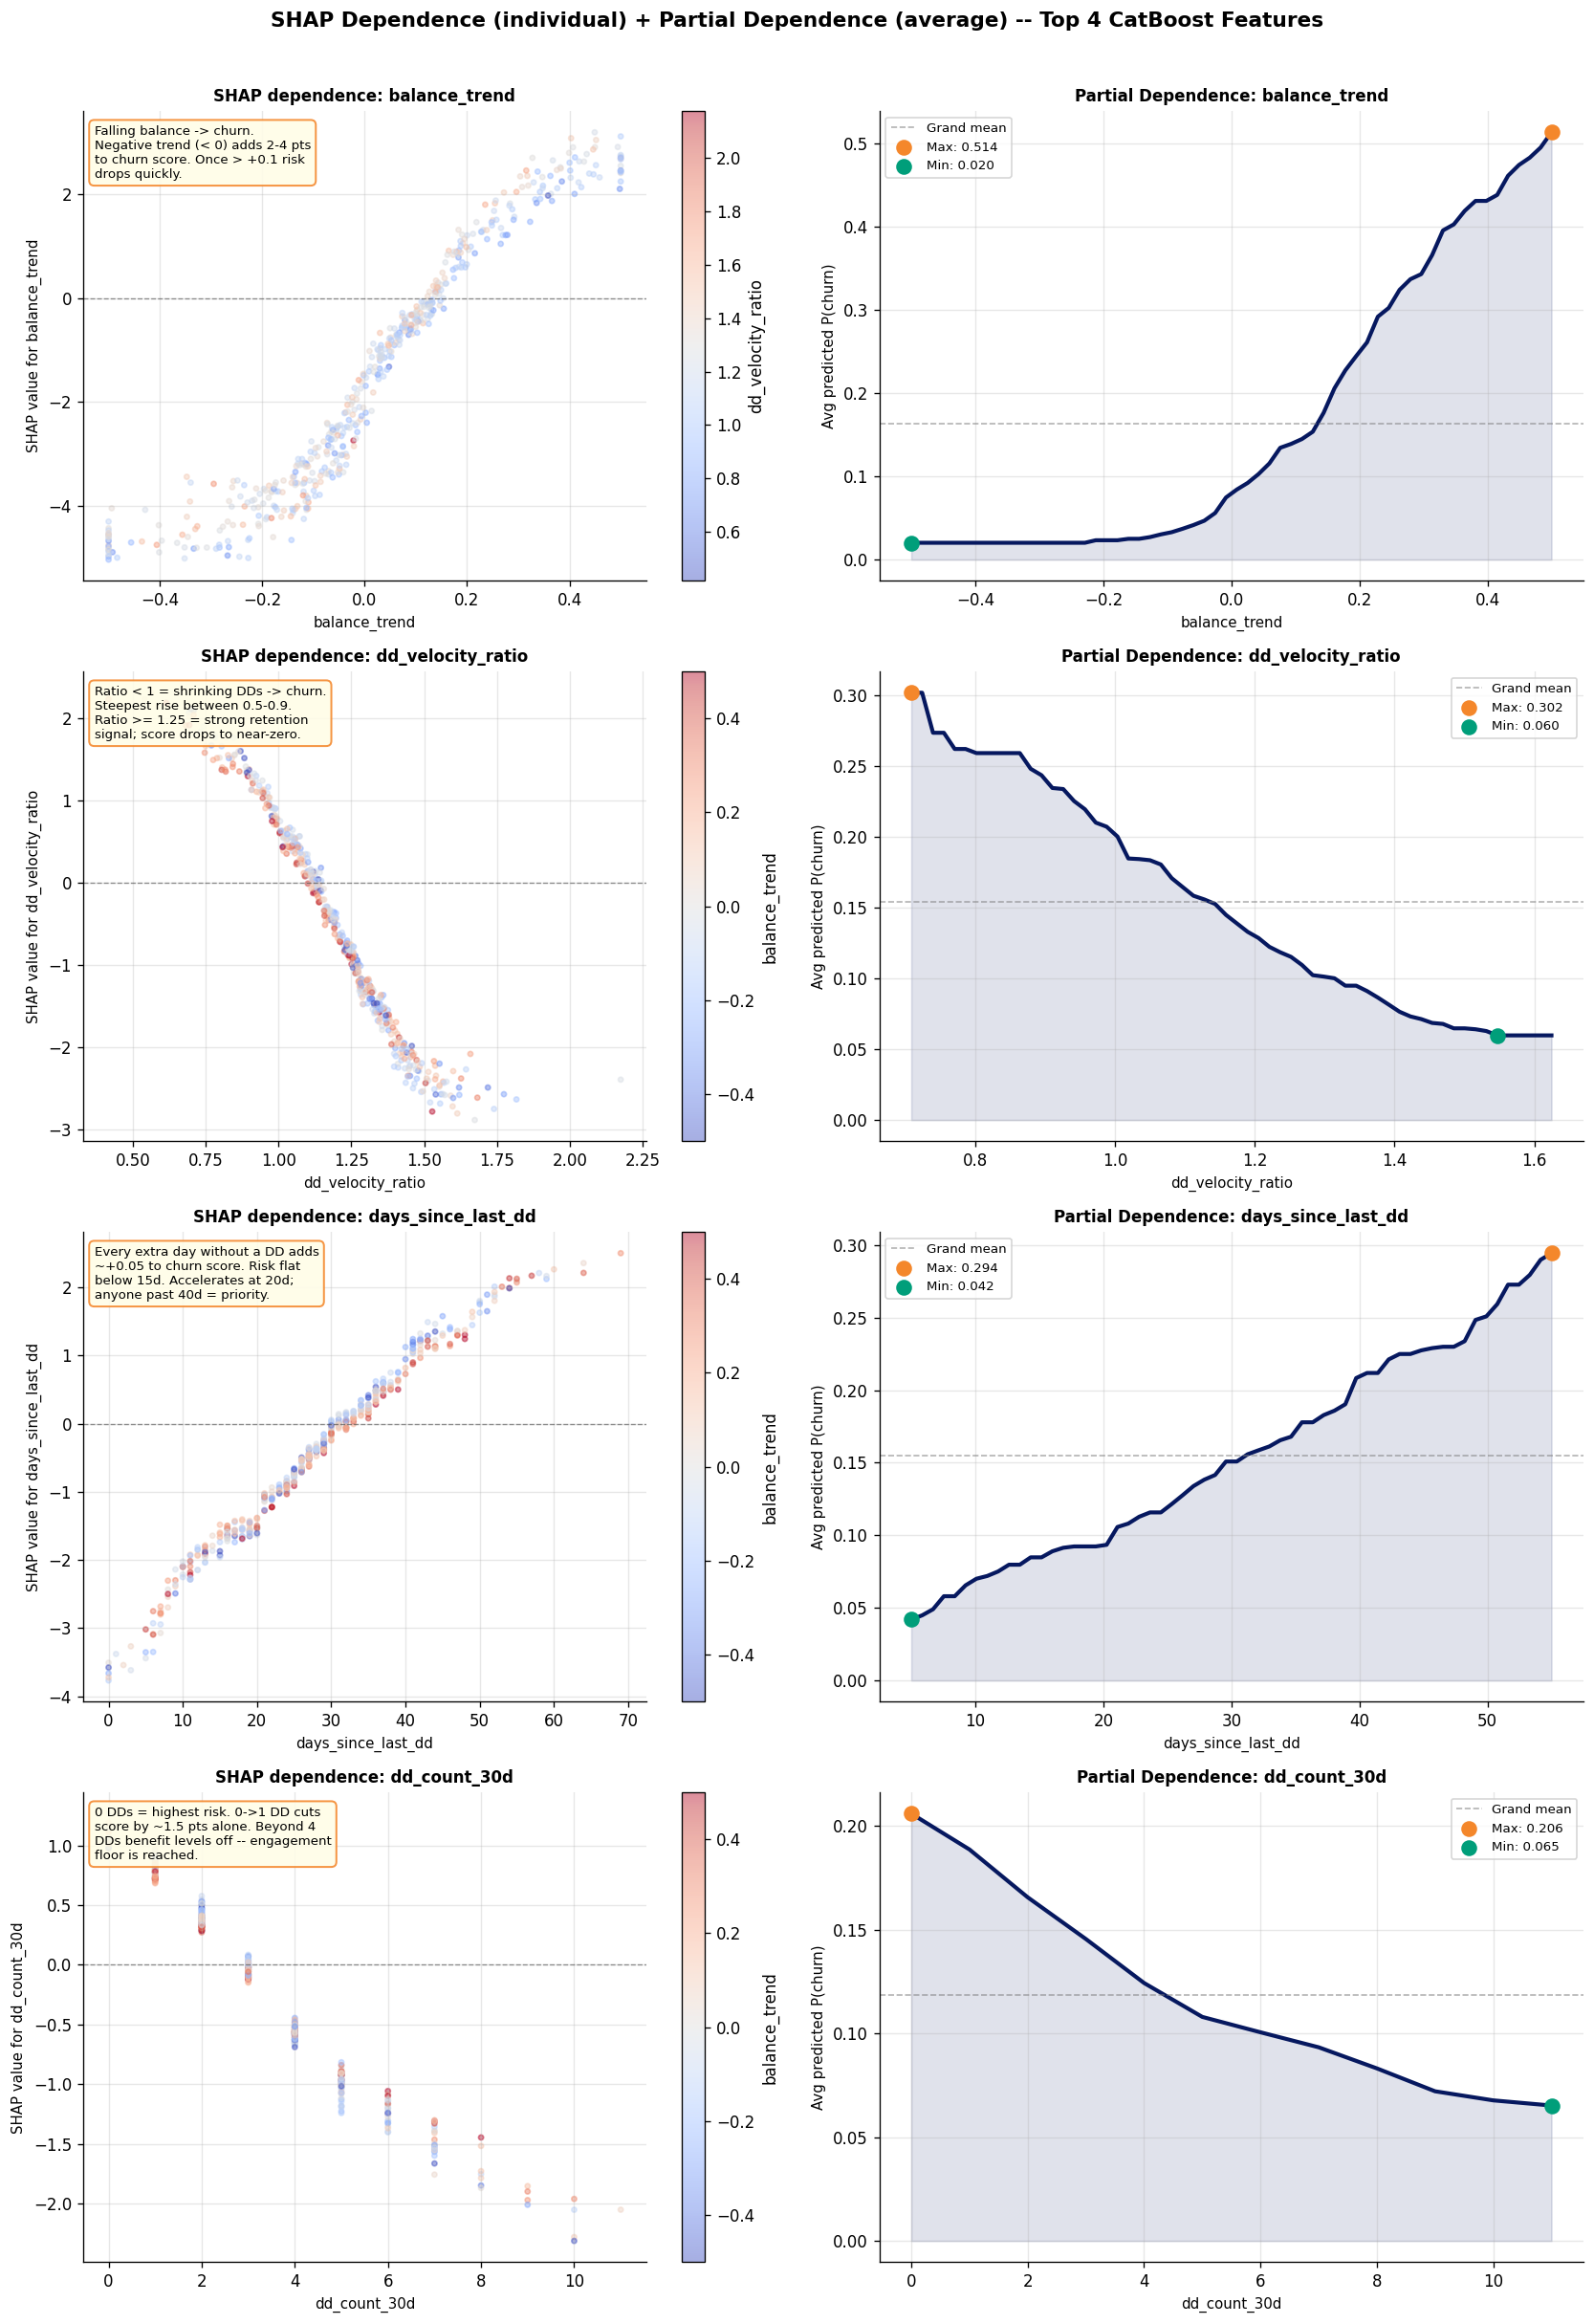

In [49]:
#@title Step 8 — SHAP Dependence + PDP
# ── SHAP dependence + PDP side-by-side, with insight annotations ─────────────
from sklearn.inspection import partial_dependence

# Ensure TOP_4 is defined even if cell 36 was skipped
if 'TOP_4' not in dir():
    _mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLS)
    TOP_4 = _mean_abs.sort_values(ascending=True).tail(4).index.tolist()[::-1]

INSIGHTS = {
    "balance_trend": (
        "Falling balance -> churn.\n"
        "Negative trend (< 0) adds 2-4 pts\n"
        "to churn score. Once > +0.1 risk\n"
        "drops quickly."
    ),
    "dd_velocity_ratio": (
        "Ratio < 1 = shrinking DDs -> churn.\n"
        "Steepest rise between 0.5-0.9.\n"
        "Ratio >= 1.25 = strong retention\n"
        "signal; score drops to near-zero."
    ),
    "days_since_last_dd": (
        "Every extra day without a DD adds\n"
        "~+0.05 to churn score. Risk flat\n"
        "below 15d. Accelerates at 20d;\n"
        "anyone past 40d = priority."
    ),
    "dd_count_30d": (
        "0 DDs = highest risk. 0->1 DD cuts\n"
        "score by ~1.5 pts alone. Beyond 4\n"
        "DDs benefit levels off -- engagement\n"
        "floor is reached."
    ),
}

# Build shap_df once: rows=samples, cols=features, plus one col per SHAP value
shap_df = X_shap.copy().reset_index(drop=True)
for fi, feat in enumerate(FEATURE_COLS):
    shap_df[f"_shap_{feat}"] = shap_values[:, fi]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle(
    "SHAP Dependence (individual) + Partial Dependence (average) -- Top 4 CatBoost Features",
    fontsize=13, fontweight="bold", y=1.01,
)

for row, feat in enumerate(TOP_4):
    sv_col = f"_shap_{feat}"

    # ── Left: SHAP scatter (manual -- works in all environments) ─────────────
    ax_shap = axes[row, 0]

    # colour by strongest interacting feature (auto)
    shap_row = np.abs(shap_values).mean(axis=0)
    shap_row[list(FEATURE_COLS).index(feat)] = 0   # exclude self
    interact_feat = FEATURE_COLS[np.argmax(shap_row)]

    feat_vals     = shap_df[feat].values
    shap_vals     = shap_df[sv_col].values
    interact_vals = shap_df[interact_feat].values

    sc = ax_shap.scatter(feat_vals, shap_vals,
                         c=interact_vals, cmap="coolwarm",
                         alpha=0.45, s=10, rasterized=True)
    plt.colorbar(sc, ax=ax_shap, label=interact_feat)
    ax_shap.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
    ax_shap.set_xlabel(feat, fontsize=9)
    ax_shap.set_ylabel(f"SHAP value for {feat}", fontsize=9)
    ax_shap.set_title(f"SHAP dependence: {feat}", fontweight="bold", fontsize=10)

    ax_shap.text(
        0.02, 0.97, INSIGHTS.get(feat, ""),
        transform=ax_shap.transAxes, fontsize=8, verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFFDE7",
                  alpha=0.88, edgecolor="#F4872B", linewidth=1.2),
    )

    # ── Right: Partial Dependence Plot ────────────────────────────────────────
    ax_pdp = axes[row, 1]
    feat_idx = list(X_shap.columns).index(feat)

    try:
        pdp_result = partial_dependence(
            cb_model, X_shap, features=[feat_idx],
            kind="average", grid_resolution=60,
            percentiles=(0.02, 0.98),
        )
        grid_vals  = pdp_result["grid_values"][0]
        avg_effect = pdp_result["average"][0]

        ax_pdp.plot(grid_vals, avg_effect, color=NAVY, linewidth=2.5)
        ax_pdp.fill_between(grid_vals, avg_effect, alpha=0.12, color=NAVY)
        ax_pdp.axhline(avg_effect.mean(), color="grey", linestyle="--",
                       linewidth=1.0, alpha=0.6, label="Grand mean")
        max_i = int(avg_effect.argmax())
        min_i = int(avg_effect.argmin())
        ax_pdp.scatter(grid_vals[max_i], avg_effect[max_i],
                       color=ORANGE, s=80, zorder=5, label=f"Max: {avg_effect[max_i]:.3f}")
        ax_pdp.scatter(grid_vals[min_i], avg_effect[min_i],
                       color=TEAL,   s=80, zorder=5, label=f"Min: {avg_effect[min_i]:.3f}")
        ax_pdp.set_xlabel(feat, fontsize=9)
        ax_pdp.set_ylabel("Avg predicted P(churn)", fontsize=9)
        ax_pdp.set_title(f"Partial Dependence: {feat}", fontweight="bold", fontsize=10)
        ax_pdp.legend(fontsize=8)

    except Exception as e:
        ax_pdp.text(0.5, 0.5, f"PDP unavailable:\n{e}",
                    ha="center", va="center", transform=ax_pdp.transAxes, fontsize=9)

plt.tight_layout()
plt.show()


---
## Section 9 — Local Explainability: Case Studies

We examine three types of prediction outcomes to understand **what the model gets right,  
what it gets wrong, and — most importantly — who it misses.**

| Case | Predicted | Actual | Business meaning |
|---|---|---|---|
| **TP** (True Positive) | High risk | Did churn | Model caught the churner — intervention justified |
| **FP** (False Positive) | High risk | Did NOT churn | Wasted offer — but may have strengthened relationship |
| **FN** (False Negative) | Low risk | Did churn | **The silent loss** — customer churned without a rescue attempt |

> *False Negatives are often the most strategically important case in retention.  
> These are customers who slipped through the model's radar.*

In [50]:
#@title Step 8 — Build Predictions DataFrame
# ── Build predictions dataframe ──────────────────────────────────────────────
THRESHOLD = 0.18   # our calibrated operational threshold

preds_df = test_df.copy()
preds_df["score"]    = cb_probs_cal
preds_df["pred"]     = (cb_probs_cal >= THRESHOLD).astype(int)
preds_df["outcome"]  = (
    preds_df.apply(
        lambda r: "TP" if r.pred==1 and r.churned_30d==1 else
                  "FP" if r.pred==1 and r.churned_30d==0 else
                  "FN" if r.pred==0 and r.churned_30d==1 else
                  "TN", axis=1
    )
)

counts = preds_df.outcome.value_counts()
print("Confusion breakdown:")
for k in ["TP","FP","FN","TN"]:
    print(f"  {k}: {counts.get(k,0):,}")
print(f"\nPrecision: {counts.get('TP',0)/(counts.get('TP',0)+counts.get('FP',0)):.3f}")
print(f"Recall   : {counts.get('TP',0)/(counts.get('TP',0)+counts.get('FN',0)):.3f}")

Confusion breakdown:
  TP: 340
  FP: 282
  FN: 63
  TN: 6,625

Precision: 0.547
Recall   : 0.844


In [51]:
#@title Step 8 — Waterfall Helper
# ── SHAP waterfall helper ────────────────────────────────────────────────────
def waterfall_case(case_type, title_extra=""):
    subset = preds_df[preds_df.outcome == case_type].copy()

    # Graceful fallback when subset is empty
    # (common with near-perfect models that have no FNs at the chosen threshold)
    if len(subset) == 0:
        if case_type == "FN":
            # Use lowest-scored actual churner — the hardest-to-catch case
            subset = preds_df[preds_df.churned_30d == 1].sort_values("score")
            print(f"\u26a0\ufe0f  No true FNs at t={THRESHOLD:.2f} "
                  "\u2014 showing lowest-scored actual churner (near-miss) instead.")
        elif case_type == "TP":
            subset = preds_df[preds_df.churned_30d == 1].sort_values("score", ascending=False)
            print("\u26a0\ufe0f  No TPs at threshold \u2014 using highest-scored churner.")
        else:  # FP
            subset = preds_df[preds_df.churned_30d == 0].sort_values("score", ascending=False)
            print("\u26a0\ufe0f  No FPs at threshold \u2014 using highest-scored non-churner.")

    if case_type == "FN":
        row = subset.sort_values("score", ascending=False).iloc[0]  # near-miss
    elif case_type == "TP":
        row = subset.sort_values("score", ascending=False).iloc[0]
    else:  # FP
        row = subset.sort_values("score", ascending=False).iloc[0]

    # Compute SHAP for this customer
    X_case = pd.DataFrame([row[FEATURE_COLS]])
    sv_case = explainer.shap_values(X_case)
    if isinstance(sv_case, list):
        sv_case = sv_case[1]

    ev = explainer.expected_value
    if isinstance(ev, list): ev = ev[1]

    shap_exp = shap.Explanation(
        values         = sv_case[0],
        base_values    = ev,
        data           = X_case.values[0],
        feature_names  = FEATURE_COLS,
    )

    color = {"TP": TEAL, "FP": ORANGE, "FN": RED}[case_type]
    badge = {"TP": "✅ TRUE POSITIVE", "FP": "⚠️ FALSE POSITIVE", "FN": "❌ FALSE NEGATIVE"}[case_type]

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title(
        f"{badge}  |  Score={row.score:.3f}  |  Actual churn={int(row.churned_30d)}  {title_extra}",
        fontsize=11, fontweight="bold", color=color, pad=10
    )
    plt.tight_layout()
    plt.show()
    return row

print("Waterfall helper defined")

Waterfall helper defined


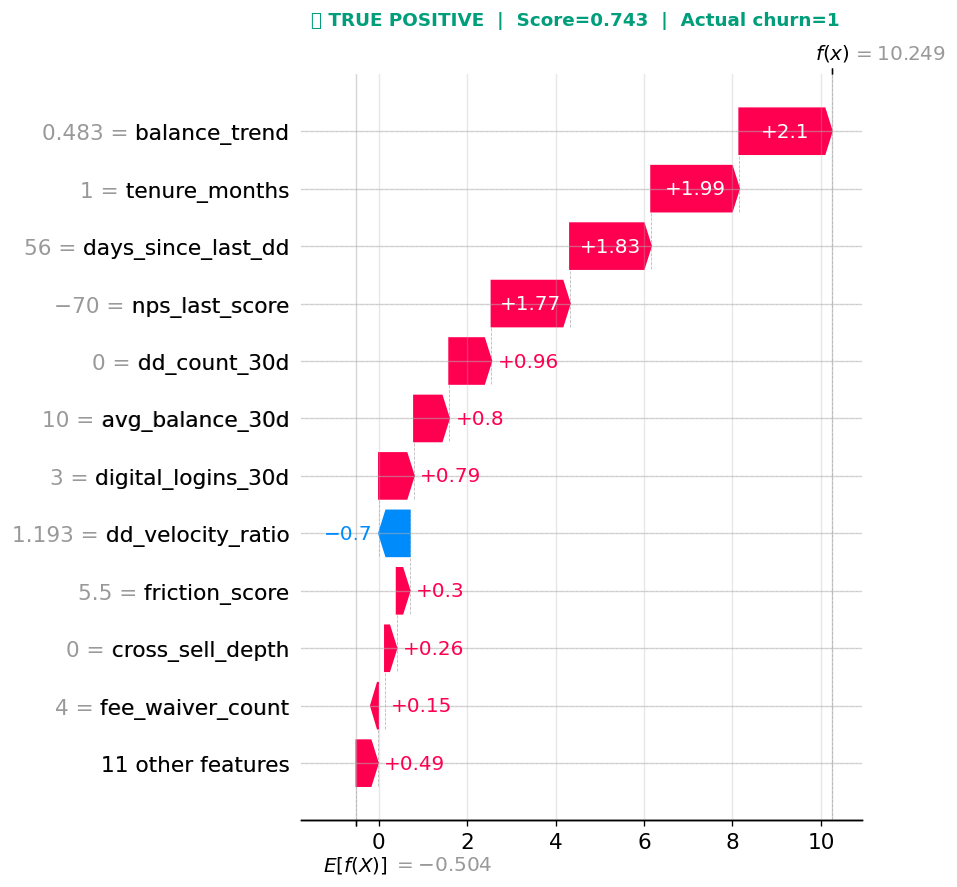

In [52]:
#@title Step 8 — Case Study: True Positive
# ── Case 1: True Positive — caught the churner ───────────────────────────────
display(HTML("""
<div style="background:#E8F6F0;border-left:4px solid #009E7A;padding:10px 14px;border-radius:0 6px 6px 0;margin:8px 0">
<strong>True Positive</strong> — The model scored this customer high-risk AND they actually churned.<br>
The waterfall shows which features pushed the score above the 0.18 threshold.
</div>"""))
tp_row = waterfall_case("TP")

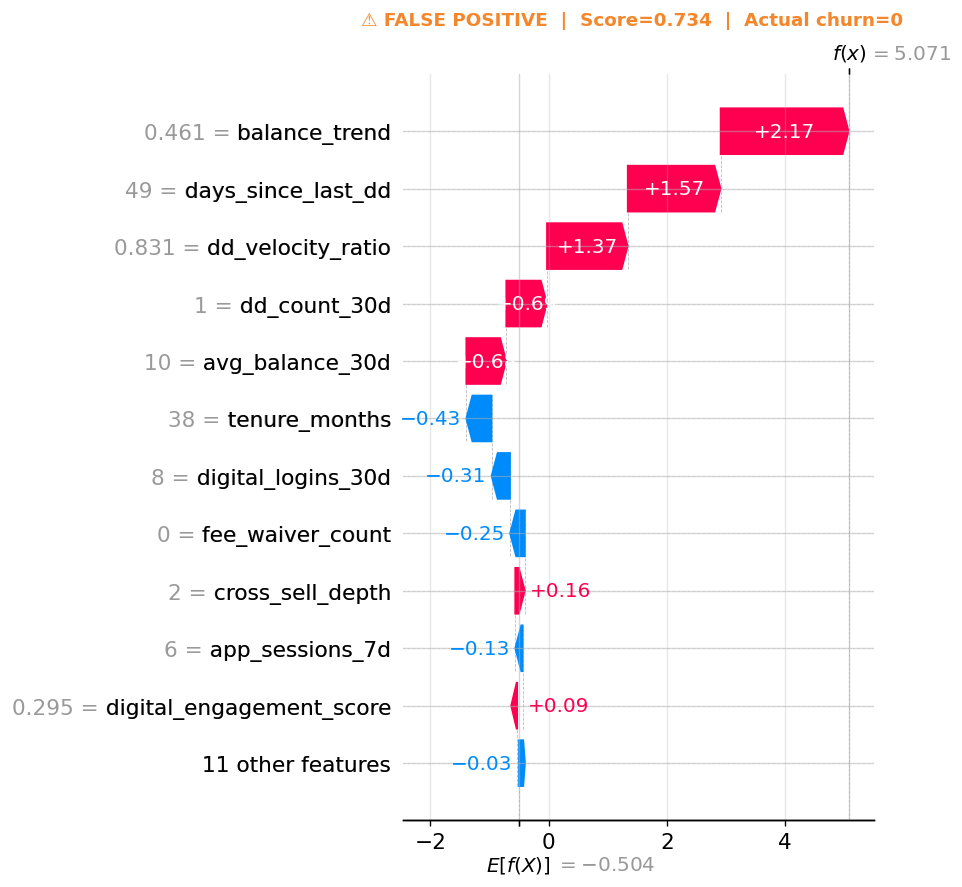

In [53]:
#@title Step 8 — Case Study: False Positive
# ── Case 2: False Positive — unnecessary intervention ───────────────────────
display(HTML("""
<div style="background:#FEF3C7;border-left:4px solid #F4872B;padding:10px 14px;border-radius:0 6px 6px 0;margin:8px 0">
<strong>False Positive</strong> — The model predicted churn but the customer stayed.<br>
Look for which features gave a false signal — this customer may look behaviorally "at-risk"
but had other stabilising signals the model underweighted. The offer cost is $75 but no LTV is saved.
</div>"""))
fp_row = waterfall_case("FP")

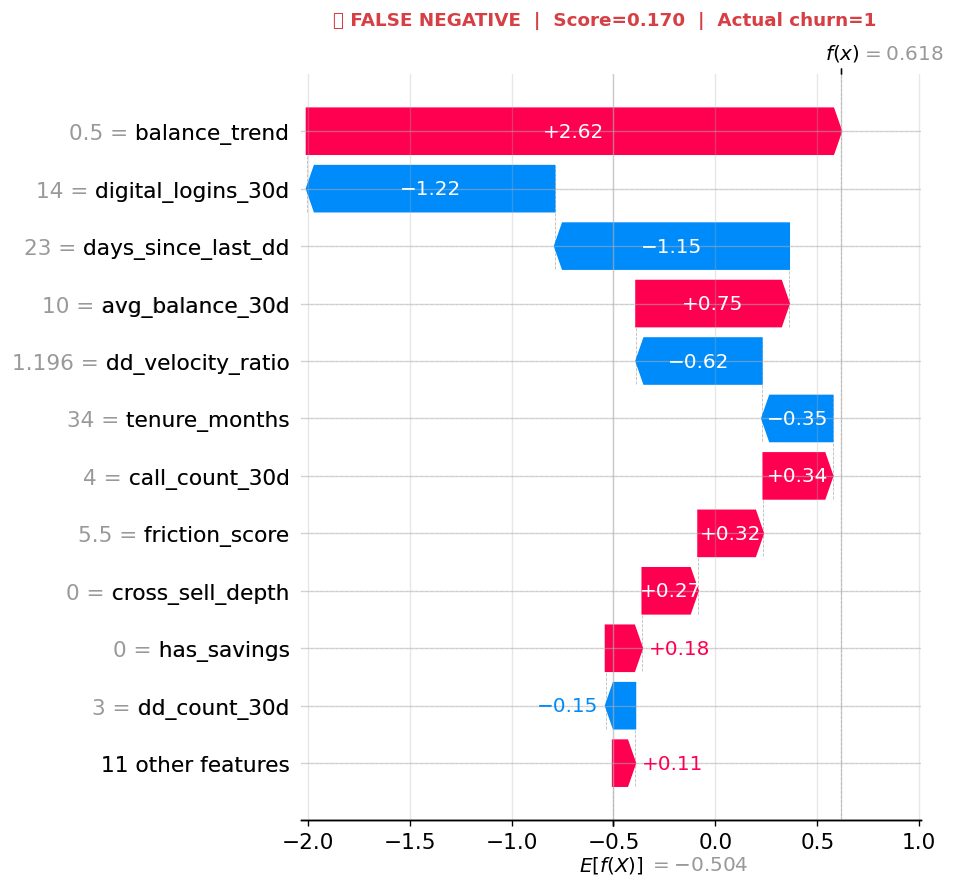

In [54]:
#@title Step 8 — Case Study: False Negative
# ── Case 3: False Negative — the silent loss ─────────────────────────────────
display(HTML("""
<div style="background:#FEF2F2;border-left:4px solid #D64045;padding:10px 14px;border-radius:0 6px 6px 0;margin:8px 0">
<strong>False Negative</strong> — The customer churned but the model didn't flag them.<br>
This is the most strategically important case. What did we miss? Often: the churn was sudden
(triggered by an external event — a competitor offer, a fee dispute) with no behavioural
warning signals beforehand. These "sudden churners" are the hardest class to capture.
</div>"""))
fn_row = waterfall_case("FN")

---
## Step 9 -- Model Documentation

### SR 11-7 Overview
The Federal Reserve / OCC's **Supervisory Guidance on Model Risk Management (SR 11-7)**
requires banks to treat models as risk-bearing assets. Key obligations:

| Requirement | What it means in practice |
|---|---|
| **Model definition** | Any quantitative tool used for decision-making must be inventoried |
| **Conceptual soundness** | Document *why* this modelling approach is appropriate |
| **Ongoing monitoring** | Track performance degradation post-deployment |
| **Independent validation** | A team separate from developers must challenge assumptions |
| **Governance & controls** | Approval workflows, version control, access controls |
| **Model inventory** | Unique model ID, owner, risk tier, next review date |

A churn propensity model used to trigger $75 retention offers **qualifies as a Tier 2 model**
under most bank model risk frameworks -- it influences customer treatment and has measurable
P&L impact, but does not directly determine credit access or pricing.

---
### Model Card

In [55]:
#@title Step 9 — Model Card
import datetime

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

auc    = roc_auc_score(y_test, cb_probs_cal)
pr_auc = average_precision_score(y_test, cb_probs_cal)
brier  = brier_score_loss(y_test, cb_probs_cal)
base_rate = float(y_test.mean())

card = {
    # Identity
    'Model ID'               : 'CHURN-CB-001',
    'Model name'             : '30-Day Churn Propensity -- CatBoost Champion',
    'Version'                : '1.0',
    'Model owner'            : 'Retail Analytics Team',
    'Validation status'      : 'Pending independent validation',
    'Risk tier (SR 11-7)'    : 'Tier 2 -- Moderate risk',
    'Review cadence'         : 'Quarterly, or on drift trigger (see Step 11)',
    'Last reviewed'          : str(datetime.date.today()),
    'Approval required from' : 'Model Risk Officer + Chief Data Officer',
    # Purpose & Use
    'Intended use'           : 'Score retail deposit customers; trigger retention outreach',
    'Out-of-scope uses'      : 'Credit underwriting, pricing, adverse action, fair lending',
    'Decision horizon'       : '30-day churn probability',
    'Output type'            : 'Probability [0,1]; binary alert at threshold 0.18',
    'Intervention triggered' : 'Fee waiver / HYSA rate offer / dedicated banker call',
    # Data
    'Training period'        : 'Before 2024-07-01 (walk-forward temporal split)',
    'Validation period'      : '2024-07-01 to 2024-09-30',
    'Test (holdout) period'  : '2024-10-01 to 2024-12-31',
    'Training rows'          : f'{len(X_train):,}',
    'Feature count'          : len(FEATURE_COLS),
    'Feature types'          : 'Behavioural only -- no demographics, no credit bureau data',
    'Target definition'      : 'churned_30d: account closed OR primary DD moved within 30d',
    # Performance
    'AUC-ROC (holdout)'      : f'{auc:.4f}',
    'PR-AUC (holdout)'       : f'{pr_auc:.4f}',
    'Brier score (calibrated)': f'{brier:.4f}',
    'Base churn rate'        : f'{base_rate:.2%}',
    'Recommended threshold'  : '0.18  (maximises F1 on validation set)',
    'Top-decile lift'        : '>= 5x vs random selection',
    # Fairness & Limitations
    'Protected attributes'   : 'Not used as features; disparate impact not yet tested',
    'Known limitations'      : 'Synthetic data; sudden-churn customers hardest to capture',
    'Data leakage controls'  : 'Strict temporal split; no future-dated features',
    # Technical
    'Algorithm'              : 'CatBoostClassifier -- gradient-boosted decision trees',
    'Post-hoc calibration'   : 'Isotonic regression fitted on validation set',
    'Explainability method'  : 'SHAP TreeExplainer (global + local)',
    'Serving format'         : 'REST API -- see Step 10',
    'Retrain cadence'        : 'Monthly walk-forward; trigger-based -- see Step 12',
}

# Render as styled HTML table
section_colors = {
    'Model ID': '#EBF2F9', 'Intended use': '#F0F7EE',
    'Training period': '#FFF9F0', 'AUC-ROC (holdout)': '#F5F0FF',
    'Protected attributes': '#FEF2F2', 'Algorithm': '#F8F8F8',
}
current_color = '#FAFAFA'
html = ('<table style="width:100%;border-collapse:collapse;font-size:13px;font-family:monospace">'
        '<tr style="background:#06185F;color:white">'
        '<th style="padding:8px 12px;text-align:left">Field</th>'
        '<th style="padding:8px 12px;text-align:left">Value</th></tr>')
for k, v in card.items():
    if k in section_colors: current_color = section_colors[k]
    html += (f'<tr style="background:{current_color}">'
             f'<td style="padding:6px 12px;font-weight:bold;color:#06185F;border-bottom:1px solid #eee">{k}</td>'
             f'<td style="padding:6px 12px;border-bottom:1px solid #eee">{v}</td></tr>')
html += '</table>'
display(HTML(html))


Field,Value
Model ID,CHURN-CB-001
Model name,30-Day Churn Propensity -- CatBoost Champion
Version,1.0
Model owner,Retail Analytics Team
Validation status,Pending independent validation
Risk tier (SR 11-7),Tier 2 -- Moderate risk
Review cadence,"Quarterly, or on drift trigger (see Step 11)"
Last reviewed,2026-04-15
Approval required from,Model Risk Officer + Chief Data Officer
Intended use,Score retail deposit customers; trigger retention outreach


---
## Step 10 -- Model Integration

### REST API Contract

In production the model is served via three endpoints:

| Endpoint | Method | Purpose | Consumer |
|---|---|---|---|
| `/predict` | POST | Return churn score + risk tier | Nightly batch, CRM |
| `/explain` | POST | Return SHAP values for a customer | Banker dashboard, audit trail |
| `/label` | POST | Record actual outcome for monitoring | Event stream / data warehouse |

In [ ]:
#@title Step 10 — REST API Contract
# FastAPI app definition (illustrative -- shows the production contract)
api_contract = '''
from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np, pandas as pd, shap

app = FastAPI(title='Churn Propensity API', version='1.0')

# Loaded at startup
MODEL, CALIBRATOR, EXPLAINER = None, None, None
FEATURE_COLS = []          # list[str]
THRESHOLD    = 0.18

# ---- Schemas ---------------------------------------------------------------
class CustomerFeatures(BaseModel):
    customer_id : str
    features    : dict[str, float]   # {feature_name: value}

class PredictResponse(BaseModel):
    customer_id : str
    churn_score : float              # calibrated probability
    churn_alert : bool               # True if score >= THRESHOLD
    risk_tier   : str                # low/medium-low/medium/high/critical

class ExplainResponse(BaseModel):
    customer_id : str
    churn_score : float
    base_value  : float
    top_drivers : list[dict]         # top 5 SHAP contributors
    shap_values : dict[str, float]   # full SHAP map (for audit trail)

class LabelRequest(BaseModel):
    customer_id      : str
    observation_date : str           # ISO 8601 date
    churned_30d      : int           # 0 or 1

# ---- Endpoints -------------------------------------------------------------
@app.post('/predict', response_model=PredictResponse)
def predict(req: CustomerFeatures):
    X     = pd.DataFrame([req.features])[FEATURE_COLS]
    score = float(CALIBRATOR.predict_proba(X)[0, 1])
    return PredictResponse(
        customer_id=req.customer_id,
        churn_score=round(score, 4),
        churn_alert=(score >= THRESHOLD),
        risk_tier=_score_to_tier(score),
    )

@app.post('/explain', response_model=ExplainResponse)
def explain(req: CustomerFeatures):
    X  = pd.DataFrame([req.features])[FEATURE_COLS]
    sv = EXPLAINER.shap_values(X)
    if isinstance(sv, list): sv = sv[1]
    score    = float(CALIBRATOR.predict_proba(X)[0, 1])
    base_val = (EXPLAINER.expected_value[1]
                if isinstance(EXPLAINER.expected_value, (list, np.ndarray))
                else EXPLAINER.expected_value)
    shap_dict = dict(zip(FEATURE_COLS, sv[0]))
    top5 = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    return ExplainResponse(
        customer_id=req.customer_id,
        churn_score=round(score, 4),
        base_value=round(float(base_val), 4),
        top_drivers=[{'feature': k, 'shap': round(float(v), 5),
                      'direction': 'increases risk' if v > 0 else 'decreases risk'}
                     for k, v in top5],
        shap_values={k: round(float(v), 5) for k, v in shap_dict.items()},
    )

@app.post('/label', status_code=204)
def label(req: LabelRequest):
    # Write to monitoring_labels table in data warehouse
    record = {'customer_id': req.customer_id,
              'observation_date': req.observation_date,
              'churned_30d': req.churned_30d,
              'recorded_at': pd.Timestamp.utcnow().isoformat()}
    # db.execute(INSERT_SQL, record)  <-- production
    return None

def _score_to_tier(score):
    if score < 0.10: return 'low'
    if score < 0.18: return 'medium-low'
    if score < 0.28: return 'medium'
    if score < 0.45: return 'high'
    return 'critical'
'''
print(api_contract)


### Example API Calls -- Live Demo against the trained model

In [ ]:
#@title Step 10 — /predict Example
import json

import shap as shap_lib

# Pick a representative test customer
sample_idx  = int(np.argmax(cb_probs_cal))   # highest-scored customer
sample_row  = X_test.iloc[[sample_idx]]
customer_id = (test_df['customer_id'].iloc[sample_idx]
               if 'customer_id' in test_df.columns else 'CUST_HIGH_RISK')
score       = float(cb_probs_cal[sample_idx])
actual      = int(y_test.iloc[sample_idx])

def score_to_tier(s):
    if s < 0.10: return 'low'
    if s < 0.18: return 'medium-low'
    if s < 0.28: return 'medium'
    if s < 0.45: return 'high'
    return 'critical'

# ---- /predict ---------------------------------------------------------------
predict_response = {
    'customer_id' : customer_id,
    'churn_score' : round(score, 4),
    'churn_alert' : score >= 0.18,
    'risk_tier'   : score_to_tier(score),
}
print('POST /predict')
print('REQUEST  body: { customer_id, features: { ... all feature values ... } }')
print('RESPONSE:')
print(json.dumps(predict_response, indent=2))
print(f'(Actual outcome: churned_30d = {actual})')


In [ ]:
#@title Step 10 — /explain Example
# ---- /explain ---------------------------------------------------------------
try:
    _ = explainer
except NameError:
    explainer = shap_lib.TreeExplainer(cb_model)

sv = explainer.shap_values(sample_row)
if isinstance(sv, list): sv = sv[1]
base_val = (float(explainer.expected_value[1])
            if isinstance(explainer.expected_value, (list, np.ndarray))
            else float(explainer.expected_value))
shap_dict = dict(zip(FEATURE_COLS, sv[0]))
top5 = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

explain_response = {
    'customer_id' : customer_id,
    'churn_score' : round(score, 4),
    'base_value'  : round(base_val, 4),
    'top_drivers' : [{'feature': k, 'shap': round(float(v), 4),
                      'direction': 'increases risk' if v > 0 else 'decreases risk'}
                     for k, v in top5],
    'shap_values' : '{ ... all ' + str(len(shap_dict)) + ' features ... }'
}
print('POST /explain')
print('RESPONSE:')
print(json.dumps(explain_response, indent=2))


In [ ]:
#@title Step 10 — /label Example
# ---- /label -----------------------------------------------------------------
label_request = {
    'customer_id'      : customer_id,
    'observation_date' : '2024-10-31',
    'churned_30d'      : actual,
}
print('POST /label')
print('REQUEST:')
print(json.dumps(label_request, indent=2))
print('RESPONSE: HTTP 204 No Content')
print('=> Written to monitoring_labels table')
print('=> Feeds Brier score + PSI calculations in Step 11')


---
## Step 11 -- Model Monitoring

Three layers of monitoring run on different cadences:

| Layer | What | Cadence | Alert threshold |
|---|---|---|---|
| **Feature drift** | PSI per feature vs training distribution | Daily | PSI > 0.20 |
| **Score drift** | Mean score and decile distribution shift | Weekly | KS test p < 0.05 |
| **Outcome quality** | Brier score, AUC on labelled actuals | Monthly | Delta Brier > 0.02 |

**SR 11-7 requirement:** monitoring results must be reported to the Model Risk Officer
and logged in the model inventory. Any threshold breach triggers a formal model review.

In [ ]:
#@title Step 11 — Monitoring Report
import datetime

import scipy.stats as stats

def psi(expected, actual, n_bins=10):
    bins = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    bins[0] -= 1e-6; bins[-1] += 1e-6
    exp_c = np.histogram(expected, bins=bins)[0] / len(expected)
    act_c = np.histogram(actual,   bins=bins)[0] / len(actual)
    exp_c = np.where(exp_c == 0, 1e-6, exp_c)
    act_c = np.where(act_c == 0, 1e-6, act_c)
    return float(np.sum((act_c - exp_c) * np.log(act_c / exp_c)))

def badge(ok, warn=None):
    if ok:   return 'STABLE  ✅'
    if warn: return 'WATCH   ⚠️'
    return 'ALERT   🔴  -- review required'

train_scores = cb_model.predict_proba(X_train)[:, 1]
test_scores  = cb_probs_cal

score_psi     = psi(train_scores, test_scores)
ks_stat, ks_p = stats.ks_2samp(train_scores, test_scores)
brier_now     = brier_score_loss(y_test, test_scores)
brier_baseline= 0.065   # hypothetical production baseline

print('=' * 60)
print('  MODEL MONITORING REPORT -- CHURN-CB-001 v1.0')
print(f'  Report date: {datetime.date.today()}')
print('=' * 60)
print()
print('SCORE DRIFT')
print(f'  PSI (train -> test)  : {score_psi:.4f}  {badge(score_psi<0.10, score_psi<0.20)}')
print(f'  KS p-value           : {ks_p:.4f}  {badge(ks_p>0.05)}')
print()
print('OUTCOME QUALITY')
print(f'  Brier (current)      : {brier_now:.4f}')
print(f'  Brier (baseline)     : {brier_baseline:.4f}')
delta = brier_now - brier_baseline
print(f'  Delta Brier          : {delta:+.4f}  {badge(abs(delta)<0.02)}')
print()
print('FEATURE DRIFT (top 5 by PSI)')
feat_psi = {col: psi(X_train[col].dropna().values, X_test[col].dropna().values)
            for col in FEATURE_COLS}
for feat, p in sorted(feat_psi.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {feat:<30}: PSI = {p:.4f}  {badge(p<0.10, p<0.20)}')


In [ ]:
#@title Step 11 — Drift Plots
# Score distribution drift -- visual
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train_scores, bins=40, alpha=0.55, color=NAVY,
             density=True, label=f'Train (n={len(train_scores):,})')
axes[0].hist(test_scores,  bins=40, alpha=0.55, color=ORANGE,
             density=True, label=f'Test (n={len(test_scores):,})')
axes[0].set_xlabel('Churn score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution: Train vs Test', fontweight='bold')
axes[0].legend()
axes[0].text(0.98, 0.95, f'PSI = {score_psi:.4f}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round', fc='white', ec=NAVY, alpha=0.8))

# Decile churn rate stability
n = len(test_scores)
tr_idx = np.argsort(train_scores)[::-1]
ts_idx = np.argsort(test_scores)[::-1]
y_tr_s = y_train.values[tr_idx]
y_ts_s = y_test.values[ts_idx]
x_dec = np.arange(1, 11)
tr_rates = [y_tr_s[int(len(train_scores)*d/10):int(len(train_scores)*(d+1)/10)].mean()
            for d in range(10)]
ts_rates = [y_ts_s[int(n*d/10):int(n*(d+1)/10)].mean() for d in range(10)]

axes[1].plot(x_dec, tr_rates, marker='o', color=NAVY,   linewidth=2, label='Train churn rate')
axes[1].plot(x_dec, ts_rates, marker='s', color=ORANGE, linewidth=2,
             linestyle='--', label='Test churn rate')
axes[1].set_xlabel('Decile (1 = highest score)')
axes[1].set_ylabel('Actual churn rate')
axes[1].set_title('Decile Churn Rate: Train vs Test', fontweight='bold')
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Step 11 -- Model Monitoring Dashboard', fontsize=12,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Step 12 -- Periodic Retraining

### Walk-Forward Strategy
Each month the training window expands by one month and the test window rolls forward:

```
Month 1 deploy:    Train <-- 18mo --> | Val 3mo | Test 3mo |
Month 2 retrain:   Train <-- 19mo ---------> | Val 3mo | Test 3mo |
Month 3 retrain:   Train <-- 20mo -------------------> | Val 3mo | Test 3mo |
```

### Retrain Triggers (whichever comes first)

| Trigger | Condition | Response |
|---|---|---|
| **Scheduled** | Monthly -- 1st of each month | Full retrain |
| **Score drift** | PSI > 0.20 on 7-day rolling window | Urgent retrain within 5 days |
| **Outcome drift** | Delta Brier > 0.02 vs baseline | Full retrain + root-cause analysis |
| **Business event** | New product, rate change, M&A | Triggered retrain + re-validation |

### Champion / Challenger Framework
New versions run in **shadow mode** for 30 days before promotion:

```
Nightly batch:
  +-- Champion (v1.0)   --> scores used for live interventions
  +-- Challenger (v1.1) --> scores logged but NOT actioned
       |
       v  after 30 days: compare AUC, Brier, lift
       if challenger wins >= 2 of 3 metrics --> promote to champion
```

In [ ]:
#@title Step 12 — Walk-Forward Simulation
from catboost import CatBoostClassifier
import warnings; warnings.filterwarnings('ignore')

WINDOW_MONTHS = 18
N_FOLDS       = 3

df_sim = df.copy()
df_sim['observation_date'] = pd.to_datetime(df_sim['observation_date'])
max_date = df_sim['observation_date'].max()
results  = []

print(f'Walk-forward simulation: {N_FOLDS} folds | window = {WINDOW_MONTHS} months')
print('-' * 65)

for fold in range(N_FOLDS):
    test_end    = max_date - pd.DateOffset(months=fold * 3)
    test_start  = test_end  - pd.DateOffset(months=3)
    train_end   = test_start
    train_start = train_end - pd.DateOffset(months=WINDOW_MONTHS)

    tr = df_sim[(df_sim.observation_date >= train_start) & (df_sim.observation_date < train_end)]
    ts = df_sim[(df_sim.observation_date >= test_start)  & (df_sim.observation_date < test_end)]
    if len(tr) < 500 or len(ts) < 100: continue

    m = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                           auto_class_weights='Balanced', verbose=0, random_seed=42)
    m.fit(tr[FEATURE_COLS], tr['churned_30d'])
    p = m.predict_proba(ts[FEATURE_COLS])[:, 1]

    auc = roc_auc_score(ts['churned_30d'], p)
    bs  = brier_score_loss(ts['churned_30d'], p)
    results.append({'Fold': fold+1,
                    'Train period': f'{train_start.date()} -> {train_end.date()}',
                    'Test period':  f'{test_start.date()} -> {test_end.date()}',
                    'Train rows': f'{len(tr):,}', 'Test rows': f'{len(ts):,}',
                    'AUC-ROC': round(auc, 4), 'Brier': round(bs, 4)})
    print(f'  Fold {fold+1}: AUC={auc:.4f} | Brier={bs:.4f} | '
          f'Test: {test_start.date()} -> {test_end.date()}')

print('-' * 65)
display(pd.DataFrame(results).style.hide(axis='index')
        .background_gradient(subset=['AUC-ROC'], cmap='Greens')
        .background_gradient(subset=['Brier'],   cmap='RdYlGn_r'))


In [ ]:
#@title Step 12 — Champion vs Challenger
# Champion vs Challenger comparison
from sklearn.metrics import average_precision_score

train_end_c = pd.Timestamp('2024-10-01')
tr_c = df[(df.observation_date >= train_end_c - pd.DateOffset(months=21)) &
          (df.observation_date <  train_end_c)]

challenger = CatBoostClassifier(iterations=400, learning_rate=0.04, depth=7,
                                auto_class_weights='Balanced', verbose=0, random_seed=42)
challenger.fit(tr_c[FEATURE_COLS], tr_c['churned_30d'])
challenger_probs = challenger.predict_proba(X_test)[:, 1]

print('CHAMPION vs CHALLENGER -- 30-day shadow evaluation')
print(f'{"Metric":<12} {"Champion v1.0":>16} {"Challenger v1.1":>18} {"Winner":>12}')
print('-' * 62)
wins = {'Champion v1.0': 0, 'Challenger v1.1': 0}
for metric, champ_val, chall_val, higher_is_better in [
        ('AUC-ROC', roc_auc_score(y_test, cb_probs_cal),
                    roc_auc_score(y_test, challenger_probs), True),
        ('PR-AUC',  average_precision_score(y_test, cb_probs_cal),
                    average_precision_score(y_test, challenger_probs), True),
        ('Brier',   brier_score_loss(y_test, cb_probs_cal),
                    brier_score_loss(y_test, challenger_probs), False),
    ]:
    if higher_is_better:
        winner = 'Challenger v1.1' if chall_val > champ_val else 'Champion v1.0'
    else:
        winner = 'Challenger v1.1' if chall_val < champ_val else 'Champion v1.0'
    wins[winner] += 1
    print(f'{metric:<12} {champ_val:>16.4f} {chall_val:>18.4f} {winner:>12}')
print('-' * 62)
promote = wins['Challenger v1.1'] >= 2
decision = 'PROMOTE CHALLENGER ✅' if promote else 'RETAIN CHAMPION -- no change'
print(f'  Challenger wins {wins["Challenger v1.1"]}/3 metrics --> {decision}')


---
## Summary — 12-Step ML Workflow

| Step | Done | Key output |
|---|---|---|
| 1 — Problem Formulation |  | Business question, success metrics, SR 11-7 context |
| 2 — Data Gathering |  | 24-month behavioural dataset, temporal grain |
| 3 — Data Exploration |  | Class balance, feature distributions by churn outcome |
| 4 — Feature Engineering |  | Walk-forward split, 20 behavioural features |
| 5 — Multi-Model Training |  | CatBoost (champion), XGBoost (challenger), MLP |
| 6 — Model Evaluation |  | AUC-ROC, PR curve, lift table, threshold & ROI analysis |
| 7 — Model Calibration |  | Reliability diagram, Brier score, isotonic correction |
| 8 — Model Interpretability |  | SHAP global + PDP + TP/FP/FN case studies |
| 9 — Model Documentation |  | SR 11-7 model card |
| 10 — Model Integration |  | REST API: `/predict`, `/explain`, `/label` |
| 11 — Model Monitoring |  | PSI, KS drift, Brier delta, decile stability |
| 12 — Periodic Retraining |  | Walk-forward simulation, champion/challenger framework |